# Лекция 4. Как распознать риск банкротства

Представим ситуацию: казначейство решает, можно ли оставить деньги в другом банке на год. В распоряжении имеется квартальная отчётность: капитал, просрочка, прибыль. Что из этого может указывать на будущее банкротство?

До сих пор мы предсказывали число: ROA или маржу. Сегодня отклик принимает два значения: банк обанкротится в течение года или нет. Это уже задача **классификации**. Модель возвращает вероятность, в реальном мире такие показатели затем трансформируются в деньги. 

Пройдём путь: **отчёт → вероятность → принятие решений → последствия решения.**

Основная часть — разделы 1–6 и итог. Подробности об оценивании, бутстрапе, балансировке, проверке по годам и скоринговой карте собраны после домашнего задания в Приложении. Их можно разобрать при желании. 

Из L03 понадобятся два приёма: целиком отправлять банк в обучение или тест и считать границы обработки признаков только по обучению.

## 0. Подготовка

Та же установочная ячейка, что в прошлых лекциях. Инструменты `sklearn` подключаем по одному, там, где они понадобятся.

In [1]:
# Библиотеки для расчётов и графиков.
import numpy as np                     # массивы и математика
import pandas as pd                    # таблицы: главный инструмент курса
import matplotlib.pyplot as plt        # рисование графиков
import seaborn as sns                  # оформление графиков
import statsmodels.formula.api as smf  # регрессии по формуле "y ~ x"

# Откуда берём данные: файлы лежат в репозитории курса, читаем их прямо по ссылке.
DATA = "https://raw.githubusercontent.com/nvvoitov/da_intro/main/data/"

# Фиксируем случайность (сид): одно и то же число -> одинаковый результат при перезапуске
SEED = 20260101

# Косметика: параметры для отображения графиков. Вникать не обязательно.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)     # размер картинки по умолчанию
pd.set_option("display.max_columns", 30)    # показывать до 30 колонок таблицы

## 1. Отчёт и событие

### 1.1 Что означает метка

В панели `failed_next_4q` равна **True, если банк обанкротился в течение 365 дней после даты отчёта**. Метка относится к паре «банк и дата»: у одного банка она со временем меняется.

Посмотрим на Wakulla Bank, закрывшийся (дефолтнувший) 1 октября 2010 года. Все величины в таблице даны долями: `0.05` означает 5 %.

In [2]:
# Читаем панель по ссылке, как в прошлых лекциях
panel = pd.read_parquet(DATA + "banks_panel.parquet")

# Последние 6 отчётов Wakulla Bank (его номер cert = 21777)
wakulla = panel[panel["cert"] == 21777]
wakulla[["repdte", "c_equity_assets", "a_npl_gross_loans", "e_roa", "failed_next_4q"]].tail(6)

,repdte,c_equity_assets,a_npl_gross_loans,e_roa,failed_next_4q
86421,2009-06-30,0.074915,0.076597,-0.037805,False
86422,2009-09-30,0.068702,0.096126,-0.058320,False
86423,2009-12-31,0.055704,0.158173,-0.053406,True
86424,2010-03-31,0.045312,0.153255,-0.064778,True
86425,2010-06-30,0.030179,0.153879,-0.071744,True
86426,2010-09-30,0.031178,0.146247,-0.006874,True


Капитал сокращается, доля просрочки растёт. Но отчёт за сентябрь 2009 года ещё помечен False: до банкротства остаётся 366 дней. У отчёта за декабрь уже True.

На рисунке каждая полоса начинается в дату отчёта и заканчивается через 365 дней. Чёрная линия показывает банкротство. Метка True появляется, когда эта линия попадает внутрь полосы.

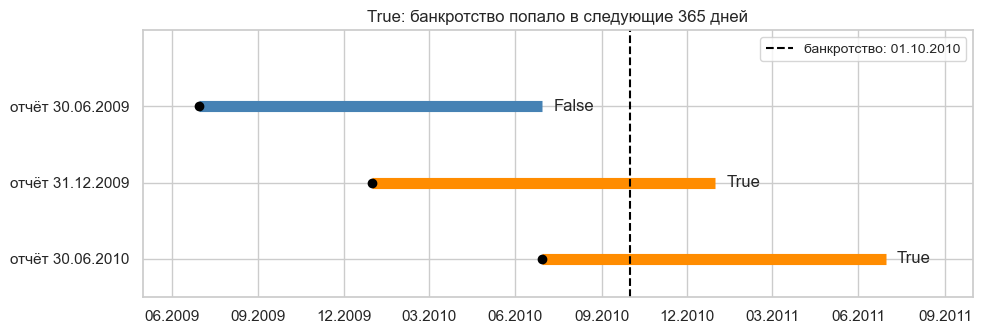

In [3]:
# @title Годовое окно для трёх отчётов Wakulla Bank
import matplotlib.dates as mdates

report_dates = pd.to_datetime(["2009-06-30", "2009-12-31", "2010-06-30"])
failure_date = pd.Timestamp("2010-10-01")
fig, ax = plt.subplots(figsize=(10, 3.5))
for row, date in enumerate(report_dates):
    end = date + pd.Timedelta(days=365)
    label = date < failure_date <= end
    color = "darkorange" if label else "steelblue"
    ax.plot([date, end], [row, row], color=color, lw=8, solid_capstyle="butt")
    ax.plot(date, row, "o", color="black", markersize=6)
    ax.text(end + pd.Timedelta(days=12), row, str(label), va="center")
ax.axvline(failure_date, color="black", ls="--", label="банкротство: 01.10.2010")
ax.set_yticks(range(3), report_dates.strftime("отчёт %d.%m.%Y"))
ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%Y"))
ax.set_xlim(pd.Timestamp("2009-05-01"), pd.Timestamp("2011-10-01"))
ax.set_ylim(2.5, -1)
ax.set_title("True: банкротство попало в следующие 365 дней")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

Перед расчётами уберём строки с неполным будущим. Данные собраны летом 2026 года; полный год наблюдения оставляем у отчётов не позже 30 июня 2025-го.

У более поздних отчётов банкротство уже могло случиться, и тогда стоит True. Но False может означать, что событие ещё не успело произойти. Для единообразия исключим все строки после границы.

Есть и задержка публикации: отчёт Wakulla за 30 сентября 2010 года датирован всего за день до закрытия. На дату отчёта его показатели ещё не были доступны пользователю. В этом учебном примере мы используем даты отчётов; для рабочего прогноза нужны даты доступности данных.

In [4]:
LABEL_END = pd.Timestamp("2025-06-30")
panel = panel[panel["repdte"] <= LABEL_END].copy()
print("отчётов с полным годом наблюдения:", len(panel))

отчётов с полным годом наблюдения: 148820


### 1.2 Редкое событие и отбор

Одна строка — квартальный отчёт. Один обанкротившийся банк может дать несколько строк с True. Поэтому доля таких строк и доля обанкротившихся банков — разные величины.

In [5]:
# Среднее от колонки True/False — это доля True
print(f"доля отчётов с банкротством в ближайший год: {panel['failed_next_4q'].mean():.2%}")
print("обанкротившихся банков:", panel.loc[panel["failed_next_4q"], "cert"].nunique(),
      "из", panel["cert"].nunique())

доля отчётов с банкротством в ближайший год: 1.56%
обанкротившихся банков: 584 из 2585


Событием заканчиваются меньше 2 % годовых окон. Скоро увидим, почему при такой доле легко получить 98 % верных ответов, вообще не прибегая к моделированию. 

Наша панель учебная: в неё включили обанкротившиеся банки и только 2000 случайно отобранных выживших. Доля события здесь не равна доле во всём банковском секторе. Все вероятности и метрики ниже относятся к этой выборке.

Банкротства ещё и неравномерно распределены во времени. В файле `failures.parquet` собраны все банкротства американских банков с 2000 года.

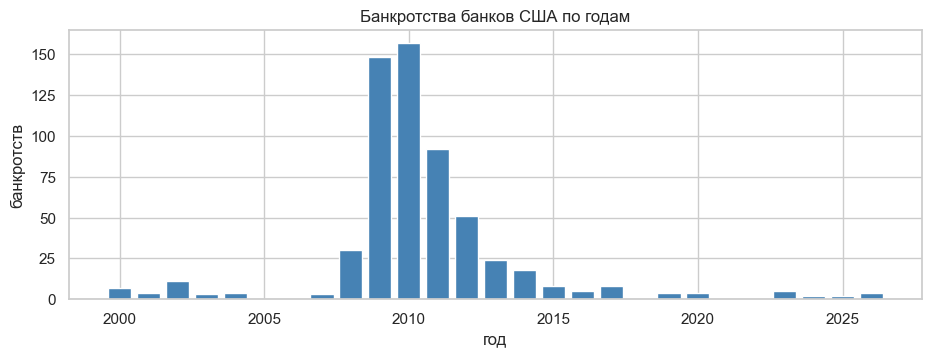

In [6]:
# @title Банкротства банков США по годам
failures = pd.read_parquet(DATA + "failures.parquet")

# Число банкротств в каждом году; годы без банкротств добавляем с нулём
per_year = failures["fail_date"].dt.year.value_counts().sort_index()
per_year = per_year.reindex(range(2000, 2027), fill_value=0)

plt.figure(figsize=(11, 3.5))
plt.bar(per_year.index, per_year.values, color="steelblue")
plt.title("Банкротства банков США по годам")
plt.xlabel("год")
plt.ylabel("банкротств")
plt.show()

Почти все банкротства пришлись на волну 2008–2012 годов; в 2005–2006 и 2021 году их не было совсем (2026 год на рисунке неполный). Модель, обученная в спокойные годы, и модель, обученная в кризис, видят очень разную «обычную» частоту события. К этому вернёмся в §5.2 и приложении D.

В прошлых лекциях мы отбирали «обычные работающие банки»: ROA от −10 % до +10 %, капитал от 2 % до 30 % активов и так далее. Посмотрим, что этот фильтр сделал бы с отчётами перед банкротством.

In [7]:
# Фильтр из лекций 1–3
old_filter = (
    (panel["assets"] > 50_000)
    & panel["e_roa"].between(-0.10, 0.10)
    & panel["m_cost_income"].between(0, 2)
    & panel["a_nco_rate"].between(0, 0.05)
    & panel["c_equity_assets"].between(0.02, 0.30)
)
failed = panel["failed_next_4q"]

# Среднее от True/False — доля строк, которые фильтр оставил; ~ означает "не"
print(f"фильтр оставил бы отчётов без события: {old_filter[~failed].mean():.0%}")
print(f"фильтр оставил бы отчётов с событием:  {old_filter[failed].mean():.0%}")

фильтр оставил бы отчётов без события: 63%
фильтр оставил бы отчётов с событием:  39%


Фильтр выбросил бы 61 % отчётов с событием и 37 % остальных. Здоровые отчёты он теряет в основном на порогах по размеру и по списаниям, а отчёты перед банкротством — на отрицательном ROA, расходах больше доходов и капитале около нуля. Для регрессии на ROA это были выбросы, для классификации это сигнал. 

Поэтому отбор мягкий: оставим банки с активами больше 50 млн долларов и без пропусков в выбранных признаках.

### 1.3 Шесть признаков

Возьмём по одному показателю из каждого блока CAMELS:

| Признак | Что измеряет |
|---|---|
| `c_equity_assets` | капитал / активы |
| `a_npl_gross_loans` | просроченные кредиты / все кредиты |
| `m_cost_income` | непроцентные расходы / чистый процентный доход |
| `e_roa` | ROA |
| `l_brokered_share` | брокерские депозиты / депозиты |
| `s_securities_assets` | ценные бумаги / активы |

`fail_date`, `failed_next_8q` и `censored` описывают будущее банка. Использовать их как признаки было бы целевой утечкой (target leakage).

In [8]:
FEATURES = ["c_equity_assets", "a_npl_gross_loans", "m_cost_income",
            "e_roa", "l_brokered_share", "s_securities_assets"]

# Мягкий отбор: активы > 50 млн $ и нет пропусков в признаках
df = panel[panel["assets"] > 50_000].dropna(subset=FEATURES).copy()

# Отклик: True/False -> 1/0, моделям удобнее числа
df["y"] = df["failed_next_4q"].astype(int)

print("отчётов:", len(df), "| банков:", df["cert"].nunique())
print(f"с банкротством в ближайший год: {df['y'].sum()} ({df['y'].mean():.2%})")

отчётов: 122144 | банков: 2290
с банкротством в ближайший год: 2061 (1.69%)


Для разбора метрик используем один набор тестовых банков во всех разделах: 30 % банков целиком, со всей историей. Отчёты одного банка не должны попасть по обе стороны границы.

Такая проверка отвечает на вопрос о других банках в те же годы. Она ещё не показывает, как модель работала бы в будущем: в обучении есть и ранние, и поздние годы. К этому вернёмся в §5.2.

In [9]:
# Перемешиваем список банков; первые 30 % целиком уходят в тест.
shuffled = df["cert"].drop_duplicates().sample(frac=1, random_state=SEED)
test_certs = shuffled.iloc[:int(0.3 * len(shuffled))]      # номера банков для теста
train = df[~df["cert"].isin(test_certs)].copy()            # ~ означает "не": все остальные банки
test = df[df["cert"].isin(test_certs)].copy()

print("обучение:", len(train), "отчётов,", train["cert"].nunique(), "банков")
print("тест:", len(test), "отчётов,", test["cert"].nunique(), "банков")

обучение: 85442 отчётов, 1603 банков
тест: 36702 отчётов, 687 банков


Очень длинные хвосты ограничим 1-м и 99-м перцентилями обучения. Строки при этом остаются в таблице. Это знакомый приём из L03, но здесь он требует осторожности: крайние значения капитала могут быть полезным сигналом.

In [10]:
# Границы считаем только по обучению и применяем к обеим частям
lower = train[FEATURES].quantile(0.01)                     # 1-й перцентиль каждого признака
upper = train[FEATURES].quantile(0.99)                     # 99-й перцентиль
train[FEATURES] = train[FEATURES].clip(lower, upper, axis=1)   # значения за границами заменяем границами
test[FEATURES] = test[FEATURES].clip(lower, upper, axis=1)

# Сколько отчётов с меткой 1 упёрлись в нижнюю границу капитала
at_floor = train.loc[train["y"] == 1, "c_equity_assets"] == lower["c_equity_assets"]
print(f"нижняя граница капитала: {lower['c_equity_assets']:.2%}")
print(f"на ней оказалось {at_floor.mean():.0%} отчётов с меткой 1")

нижняя граница капитала: 2.75%
на ней оказалось 38% отчётов с меткой 1


У 38 % обучающих отчётов с меткой 1 капитал теперь одинаковый. Обрезка избавляет расчёт от крайних значений, но стирает различия в наиболее информативном хвосте. Оставим обрезку ради единообразия с L03; нужна ли она именно этой модели, пришлось бы отдельно проверить на валидации.

## 2. Из капитала в вероятность

### 2.1 Почему пробуем кривую

Если в группе похожих отчётов 20 из 100 получили метку 1, частота события в этой группе равна 20 %. Начнём с такого расчёта без модели: разобьём обучающие отчёты по доле (достаточности) капитала.

`pd.cut` назначает каждой строке интервал, `groupby` собирает строки одного интервала. Среднее от нулей и единиц даёт долю события.

In [11]:
# Корзины капитала: pd.cut режет числа на интервалы с заданными границами.
# Капитал обрезан снизу (§1.3); первая корзина включает и значения на границе.
edges = [0, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12, 0.15, 0.20, 1]
train["equity_bin"] = pd.cut(train["c_equity_assets"], edges)

# В каждой корзине: средний капитал, доля банкротств и число отчётов
by_bin = train.groupby("equity_bin", observed=True).agg(
    equity=("c_equity_assets", "mean"),
    share_failed=("y", "mean"),
    n=("y", "size"))
by_bin.round(4)

,equity,share_failed,n
equity_bin,,,
"(0.0, 0.03]",0.0276,0.6209,955
"(0.03, 0.04]",0.0352,0.3626,535
"(0.04, 0.05]",0.0454,0.2256,625
"(0.05, 0.06]",0.0558,0.1002,1337
"(0.06, 0.07]",0.0659,0.0289,3525
"(0.07, 0.08]",0.0755,0.0122,9044
"(0.08, 0.09]",0.0851,0.0051,14329
"(0.09, 0.1]",0.0949,0.0029,14609
"(0.1, 0.12]",0.1089,0.0019,20336


В первой группе доля события больше половины, при капитале 6–7 % — около 3 %. Затем она становится совсем небольшой.

Попробуем две модели на тех же отдельных отчётах: привычную прямую МНК и логистическую регрессию. В `statsmodels` меняется одно слово: `ols` на `logit`.

In [12]:
lpm = smf.ols("y ~ c_equity_assets", data=train).fit()               # прямая МНК на откликах 0/1
logit1 = smf.logit("y ~ c_equity_assets", data=train).fit(disp=0)    # логистическая регрессия; disp=0 — не печатать шаги

# .fittedvalues — прогнозы прямой на обучающих строках
print(f"прогноз прямой меньше нуля у {(lpm.fittedvalues < 0).mean():.0%} обучающих отчётов")

# Сетка нужна только для гладких линий на рисунке.
x_grid = np.linspace(0.02, 0.25, 200)
grid = pd.DataFrame({"c_equity_assets": x_grid})
line = lpm.predict(grid)                                   # высота прямой на сетке
curve = logit1.predict(grid)                               # вероятность по логистической модели

прогноз прямой меньше нуля у 20% обучающих отчётов


Точки на рисунке — частоты из таблицы. Модели обучались на исходных строках, поэтому проходить через каждую точку они не обязаны. Посмотрим, какая форма лучше передаёт быстрое падение риска.

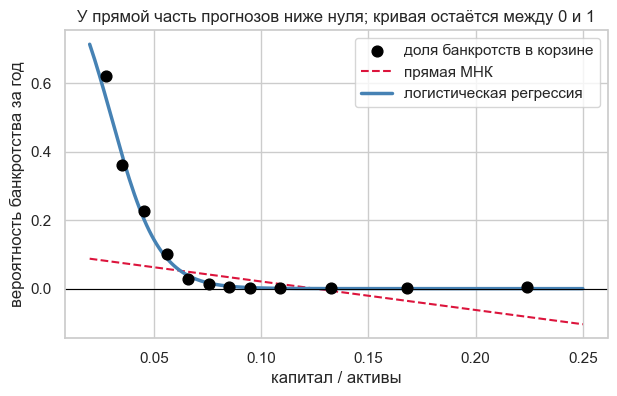

In [13]:
# @title Прямая и логистическая кривая на одних данных
plt.scatter(by_bin["equity"], by_bin["share_failed"], s=60, color="black", zorder=5, label="доля банкротств в корзине")
plt.plot(x_grid, line, color="crimson", lw=1.5, ls="--", label="прямая МНК")
plt.plot(x_grid, curve, color="steelblue", lw=2.5, label="логистическая регрессия")
plt.axhline(0, color="black", lw=0.8)
plt.title("У прямой часть прогнозов ниже нуля; кривая остаётся между 0 и 1")
plt.xlabel("капитал / активы")
plt.ylabel("вероятность банкротства за год")
plt.legend()
plt.show()

У прямой примерно пятая часть обучающих прогнозов отрицательна. Логистическая кривая остаётся между 0 и 1 и улавливает основную форму зависимости. Она всё ещё может ошибаться, особенно там, где событий мало.

### 2.2 Что делает логистическая регрессия

Модель сначала считает линейную комбинацию $z = \beta_0 + \beta_1 x$, как обычная регрессия. Затем превращает это число в вероятность:

$$p = \frac{1}{1+e^{-z}}.$$

Эта функция называется **сигмоидой**. При $z=0$ вероятность равна 0.5; отрицательные $z$ дают значения меньше 0.5, положительные — больше.

Коэффициенты выбираются так, чтобы наблюдавшиеся исходы получали более высокие вероятности. Например, за случившееся банкротство прогноз 1 % штрафуется сильнее, чем прогноз 40 %. Подробный критерий и его график — в приложении A.

У модели с одним капиталом коэффициент около −90. Он относится к логарифму **шансов**: шансы равны $p/(1-p)$. При вероятности 20 % это $0.2/0.8=1/4$: на одно событие приходится четыре несобытия.

Увеличение капитала на 1 п.п. означает прибавку `0.01` к признаку. Шансы тогда умножаются на $e^{\beta_1\cdot0.01}$. Вероятности удобнее получить через `.predict()`.

In [14]:
b1 = logit1.params["c_equity_assets"]
print(f"при +1 п.п. капитала шансы умножаются на {np.exp(b1 * 0.01):.2f}")

# Вероятности для нескольких значений капитала.
levels = pd.DataFrame({"c_equity_assets": [0.03, 0.05, 0.07, 0.09, 0.11]})
levels["вероятность"] = logit1.predict(levels).round(4)
levels

при +1 п.п. капитала шансы умножаются на 0.41


,c_equity_assets,вероятность
0,0.03,0.5036
1,0.05,0.1431
2,0.07,0.0267
3,0.09,0.0045
4,0.11,0.0007


Шансы каждый раз умножаются примерно на 0.41. Изменение вероятности зависит от исходной точки: на крутом участке разница большая, около нуля — небольшая.

Чтобы узнать изменение при +1 п.п. капитала, посчитаем два прогноза: до прибавки и после. Это ассоциативная связь, описанная моделью. Поэтому из неё не следует, что докапитализация реального банка вызовет именно такое изменение риска.

In [15]:
capital_before = pd.DataFrame({"c_equity_assets": [0.04, 0.06, 0.10]})   # три банка с разным капиталом
capital_after = capital_before + 0.01                                      # тот же банк с капиталом на 1 п.п. больше
p_before = logit1.predict(capital_before)                                  # прогноз до прибавки
p_after = logit1.predict(capital_after)                                    # и после неё

# Всё переводим в проценты и процентные пункты
pd.DataFrame({
    "капитал до, %": 100 * capital_before["c_equity_assets"],
    "вероятность до, %": 100 * p_before,
    "вероятность после, %": 100 * p_after,
    "изменение, п.п.": 100 * (p_after - p_before),
}).round(2)

,"капитал до, %","вероятность до, %","вероятность после, %","изменение, п.п."
0,4.0,29.16,14.31,-14.85
1,6.0,6.34,2.67,-3.67
2,10.0,0.18,0.07,-0.11


При переходе от 4 % к 5 % капитала прогноз уменьшается примерно на 15 п.п.; от 10 % к 11 % — примерно на 0.1 п.п. Обе разницы получены из одной кривой. Предельный эффект описывает её локальный наклон; сравнение наклона с конечным шагом — в §2.4.

### 2.3 Добавим остальные признаки

Соберём формулу из шести признаков. Кластерные по банкам стандартные ошибки учитывают зависимость квартальных отчётов одного банка. Этот приём уже был во второй лекции; сами прогнозы он не меняет.

In [16]:
formula = "y ~ " + " + ".join(FEATURES)                   # склеиваем "y ~ c_equity_assets + a_npl_gross_loans + ..."
# cov_type="cluster" — стандартные ошибки с группировкой по банку (отчёты одного банка зависимы)
logit6 = smf.logit(formula, data=train).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": train["cert"]})

logit6.summary()                                          # стандартная таблица statsmodels

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                85442
Model:                          Logit   Df Residuals:                    85435
Method:                           MLE   Df Model:                            6
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                  0.6123
Time:                        00:59:34   Log-Likelihood:                -2854.0
converged:                       True   LL-Null:                       -7360.4
Covariance Type:              cluster   LLR p-value:                     0.000
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.4855      0.376     -1.290      0.197      -1.223       0.252
c_equity_assets       -55.0699      4.434    -12.419      0.000     -63.761     -46.379
a_npl_gross_loans      19.5649      1.304     14.999      0.000      17.008      22.122
m_cost_income           0.0574      0.102      0.563      0.573      -0.142       0.257
e_roa                 -22.1766      2.119    -10.466      0.000     -26.330     -18.024
l_brokered_share        3.1898      0.552      5.782      0.000       2.109       4.271
s_securities_assets    -4.9450      0.729     -6.784      0.000      -6.374      -3.516
=======================================================================================

Possibly complete quasi-separation: A fraction 0.14 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

Таблица читается так же, как во второй лекции, с несколькими отличиями.

В шапке `No. Observations` — число обучающих отчётов, `Df Model` — число признаков, `converged: True` — численный поиск коэффициентов сошёлся (как он устроен, показано в приложении A). `Covariance Type: cluster` означает, что все стандартные ошибки ниже кластерные по банкам. Вместо $R^2$ здесь `Pseudo R-squ.` — псевдо-$R^2$ Макфаддена: на какую долю логарифм правдоподобия модели (`Log-Likelihood`) лучше, чем у модели с одним свободным членом (`LL-Null`). Шкала у него своя, сравнивать его с $R^2$ МНК не стоит. `LLR p-value` проверяет гипотезу «все наклоны равны нулю», это аналог $F$-теста.

В теле `coef` — изменение лог-шансов при росте признака на единицу. Наши признаки записаны долями, поэтому единица здесь — это 100 п.п.; для +1 п.п. коэффициент умножаем на 0.01. Вместо $t$ стоит $z$: коэффициент, делённый на стандартную ошибку, его сравнивают с нормальным распределением. `P>|z|` — $p$-значение для гипотезы «коэффициент равен нулю», `[0.025 0.975]` — 95%-интервал.

Прочитаем две строки. У капитала коэффициент около −55: при +1 п.п. лог-шансы уменьшаются на 0.55, шансы умножаются на $e^{-0.55} \approx 0.58$, а $z$ около −12. В модели с одним капиталом коэффициент был −90: часть его связи с риском теперь приходится на просрочку и ROA. У расходов к доходам $p \approx 0.57$ и интервал накрывает ноль: при остальных признаках связи не видно.

Под таблицей `statsmodels` может предупредить о квази-разделении (quasi-separation): у части отчётов вероятность так близка к 0 или 1, что исход предсказывается почти идеально. При редком событии это обычно очень здоровые банки. Проблемой это было бы, если бы поиск не сошёлся или коэффициенты уходили в бесконечность; здесь `converged: True`, а стандартные ошибки конечные.

Коэффициенты в лог-шансах разных признаков напрямую не сравнить: у признаков разный разброс. Переведём их в множители шансов при прибавке в одно стандартное отклонение.

Рядом с множителями покажем 95%-интервалы с кластерными ошибками.

In [17]:
sd = train[FEATURES].std()                                 # стандартное отклонение каждого признака
beta_interval = logit6.conf_int().loc[FEATURES]            # 95%-интервалы коэффициентов (кластерные)

# exp(коэффициент * sd) — во сколько раз меняются шансы при +1 sd признака
odds_table = pd.DataFrame({
    "шансы × при +1 sd": np.exp(logit6.params[FEATURES] * sd),
    "нижняя граница": np.exp(beta_interval[0] * sd),
    "верхняя граница": np.exp(beta_interval[1] * sd),
})
odds_table.round(3)

,шансы × при +1 sd,нижняя граница,верхняя граница
c_equity_assets,0.154,0.115,0.207
a_npl_gross_loans,1.684,1.573,1.803
m_cost_income,1.025,0.940,1.119
e_roa,0.732,0.690,0.776
l_brokered_share,1.308,1.194,1.433
s_securities_assets,0.477,0.386,0.591


Множитель меньше 1 означает меньшие шансы при прочих равных, больше 1 — большие. Капитал, ROA и доля ценных бумаг связаны с меньшим прогнозом риска; просрочка и брокерские депозиты — с большим. У расходов к доходам интервал включает 1: выраженной связи после учёта остальных признаков здесь не видно.

Это описание нашей выборки. Например, отрицательный коэффициент при ценных бумагах ещё не означает, что любой портфель облигаций защищает банк. Вернёмся к этому в §5.2.

### 2.4 Предельные эффекты: почему прибавка капитала меняет вероятность по-разному

На пологом участке кривой один процентный пункт капитала мало меняет прогноз; на крутом участке разница заметнее. **Предельный эффект** — наклон кривой именно в выбранной точке:

$$\frac{\partial p}{\partial x}=\beta p(1-p).$$

Это локальная производная. Для конечного шага $\Delta x$ она даёт приближение $\Delta p\approx\beta p(1-p)\Delta x$. Точную разницу получаем двумя прогнозами: $p(x+\Delta x)-p(x)$. Сравним касательные в трёх точках.


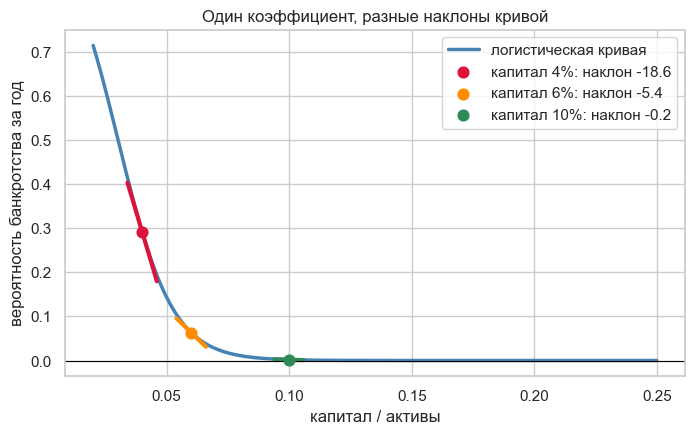

In [18]:
b1 = logit1.params["c_equity_assets"]                     # наклон модели с одним капиталом (§2.2)
logit6_cl = logit6                                        # в §2.3 модель уже оценена с кластерными ошибками

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_grid, curve, color="steelblue", lw=2.5, label="логистическая кривая")
for equity, color in [(0.04, "crimson"), (0.06, "darkorange"), (0.10, "seagreen")]:
    p0 = logit1.predict(pd.DataFrame({"c_equity_assets": [equity]})).iloc[0]   # вероятность в точке
    slope = b1 * p0 * (1 - p0)                            # предельный эффект: наклон в этой точке
    segment = np.array([equity - 0.006, equity + 0.006])  # короткий отрезок касательной
    ax.plot(segment, p0 + slope * (segment - equity), color=color, lw=3)
    ax.scatter([equity], [p0], s=60, color=color, zorder=5,
               label=f"капитал {equity:.0%}: наклон {slope:.1f}")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Один коэффициент, разные наклоны кривой")
ax.set_xlabel("капитал / активы")
ax.set_ylabel("вероятность банкротства за год")
ax.legend()
plt.show()

Теперь увеличим капитал ровно на 1 п.п. В последней колонке будет фактическое изменение прогноза модели; в предпоследней — приближение по касательной. Там, где кривая заметно изгибается на этом шаге, числа различаются.


In [19]:
effect_points = pd.DataFrame({"c_equity_assets": [0.04, 0.06, 0.10]})     # три точки на кривой
p_before = logit1.predict(effect_points)                                    # прогноз в точке
p_after = logit1.predict(effect_points.assign(                              # прогноз после +1 п.п.
    c_equity_assets=effect_points["c_equity_assets"] + 0.01))

# Наклон b*p*(1-p) — сразу в п.п. вероятности на +1 п.п. признака; точное изменение — разница прогнозов
pd.DataFrame({
    "капитал до, %": 100 * effect_points["c_equity_assets"],
    "вероятность до, %": 100 * p_before,
    "вероятность после, %": 100 * p_after,
    "по касательной, п.п.": b1 * p_before * (1 - p_before),
    "точное изменение, п.п.": 100 * (p_after - p_before),
}).round(3)

,"капитал до, %","вероятность до, %","вероятность после, %","по касательной, п.п.","точное изменение, п.п."
0,4.0,29.158,14.307,-18.638,-14.851
1,6.0,6.343,2.674,-5.360,-3.669
2,10.0,0.183,0.074,-0.165,-0.109


В первой строке приближение особенно грубое: шаг в 1 п.п. слишком велик, чтобы считать этот участок прямым. Поэтому производную нельзя называть точным эффектом прибавки в 1 п.п.

Для модели с шестью признаками наклон свой в каждой строке. `get_margeff(at="overall")` усредняет эти наклоны; `at="mean"` считает один наклон в точке со средними значениями признаков.

Единицы здесь удобны: и признак, и вероятность записаны долями. Число $\partial p/\partial x$ поэтому равно локальному изменению в п.п. вероятности на 1 п.п. признака. Сравним средний наклон по капиталу ещё и с точным сдвигом всех обучающих отчётов на 1 п.п.


In [20]:
ame = logit6_cl.get_margeff(at="overall")                 # средний предельный эффект: наклон в каждой строке, потом среднее
mem = logit6_cl.get_margeff(at="mean")                    # наклон в одной точке — у «среднего банка»
marginal_table = pd.DataFrame({
    "средний наклон": ame.summary_frame()["dy/dx"],
    "z, кластерный": ame.summary_frame()["z"],
    "наклон у «среднего банка»": mem.summary_frame()["dy/dx"],
})
print(marginal_table.round(3))

# Точный вариант для капитала: прибавим 0.01 всем обучающим отчётам и усредним разницу прогнозов
p_train = logit6.predict(train)
shifted_train = train.assign(c_equity_assets=train["c_equity_assets"] + 0.01)
exact_average = 100 * (logit6.predict(shifted_train) - p_train).mean()
print(f"Капитал: средний наклон {marginal_table.loc['c_equity_assets', 'средний наклон']:.3f}")
print(f"Капитал: среднее точное изменение при +1 п.п. {exact_average:.3f} п.п.")

                     средний наклон  z, кластерный  наклон у «среднего банка»
c_equity_assets              -0.455        -14.800                     -0.052
a_npl_gross_loans             0.162         12.994                      0.019
m_cost_income                 0.000          0.564                      0.000
e_roa                        -0.183         -9.330                     -0.021
l_brokered_share              0.026          5.680                      0.003
s_securities_assets          -0.041         -6.609                     -0.005
Капитал: средний наклон -0.455
Капитал: среднее точное изменение при +1 п.п. -0.407 п.п.


Усреднять наклоны и считать наклон при средних признаках — не одно и то же. «Средний банк» может оказаться на плоском участке, хотя в выборке есть банки на крутом. Посмотрим, какие отчёты определяют средний наклон по капиталу.


In [21]:
me_equity = logit6.params["c_equity_assets"] * p_train * (1 - p_train)     # наклон по капиталу в каждой строке
risk_group = pd.cut(p_train, [0, 0.001, 0.01, 0.1, 0.5, 1], include_lowest=True)   # группы по прогнозу риска

pd.DataFrame({
    "доля отчётов": risk_group.value_counts(normalize=True, sort=False),   # sort=False — в порядке групп
    "средний наклон по капиталу": me_equity.groupby(risk_group, observed=True).mean(),
}).rename_axis("вероятность по модели").round(3)

,доля отчётов,средний наклон по капиталу
вероятность по модели,,
"(-0.001, 0.001]",0.461,-0.019
"(0.001, 0.01]",0.446,-0.173
"(0.01, 0.1]",0.063,-1.462
"(0.1, 0.5]",0.017,-9.595
"(0.5, 1.0]",0.013,-9.146


В группах с очень низкой вероятностью наклон близок к нулю. Отчёты с более высоким риском сильнее влияют на средний наклон. Поэтому рядом с «эффектом на вероятность» всегда нужно уточнять, где он измерен и является ли он производной или точной разницей двух прогнозов.

Все эти расчёты описывают связь, которую выучила модель. Они не показывают, как изменился бы риск после реальной докапитализации банка.


## 3. Когда поднимать тревогу

### 3.1 Прогнозы тестовых банков

Применим модель к банкам, которые целиком оставили для проверки. Средняя вероятность полезна как первый ориентир, но она ещё не говорит, какие именно отчёты модель считает опасными.

In [22]:
test["p"] = logit6.predict(test)           # вероятность банкротства в ближайший год

print(f"средняя вероятность по модели: {test['p'].mean():.4f}")
print(f"доля банкротств на самом деле: {test['y'].mean():.4f}")

средняя вероятность по модели: 0.0184
доля банкротств на самом деле: 0.0166


На рисунке показаны прогнозы отдельно для двух исходов. Каждая группа нормирована отдельно, чтобы редкие события были видны; площадь кривых не показывает соотношение размеров групп.

Вероятности меняются в сотни раз, поэтому ось X логарифмическая. Пунктир пока поставим на 0.5: справа от него будем поднимать тревогу.

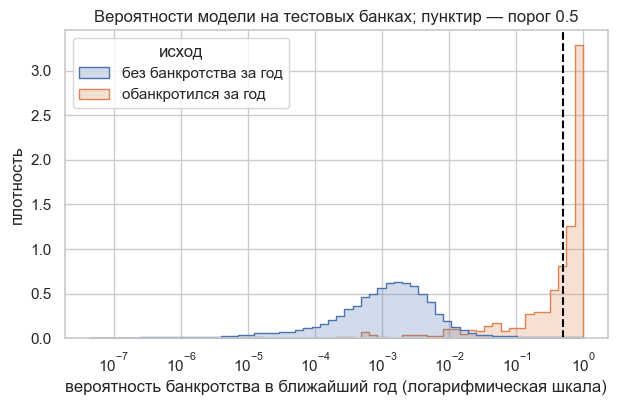

In [23]:
# @title Как распределены прогнозы двух классов
test["исход"] = np.where(test["y"] == 1, "обанкротился за год", "без банкротства за год")

# stat="density", common_norm=False — каждая группа нормирована отдельно,
# иначе 600 отчётов с банкротством не было бы видно рядом с 36 тысячами остальных
sns.histplot(data=test, x="p", hue="исход", log_scale=True, bins=60,
             stat="density", common_norm=False, element="step")
plt.axvline(0.5, color="black", ls="--", lw=1.5)
plt.title("Вероятности модели на тестовых банках; пунктир — порог 0.5")
plt.xlabel("вероятность банкротства в ближайший год (логарифмическая шкала)")
plt.ylabel("плотность")
plt.show()

Группы заметно разделены, но перекрываются. Поэтому любое решение будет сопровождаться ошибками.

### 3.2 Четыре возможных исхода

**Порог** $t$ превращает вероятность в решение: поднимаем тревогу, если $p \ge t$. При пороге 0.5 посчитаем **матрицу ошибок** (confusion matrix). Строки показывают факт, столбцы — решение модели.

Все числа здесь и дальше относятся к отчётам. Повторные сигналы по одному банку считаются отдельно.

In [24]:
from sklearn.metrics import confusion_matrix

threshold = 0.5
test["flag"] = (test["p"] >= threshold).astype(int)     # 1 — модель поднимает тревогу

# confusion_matrix(факт, ответ модели) -> таблица 2x2: [[TN, FP], [FN, TP]]
cm = confusion_matrix(test["y"], test["flag"], labels=[0, 1])
tn, fp, fn, tp = cm.ravel()                  # .ravel() — вытянуть таблицу 2x2 в четыре числа
# Четыре числа покажем на рисунке ниже.

Оранжевые клетки — два вида ошибок. Ложная тревога означает, что мы пометили отчёт, за которым банкротства в течение года не последовало. Пропуск означает, что банкротство случилось, а тревоги не было.

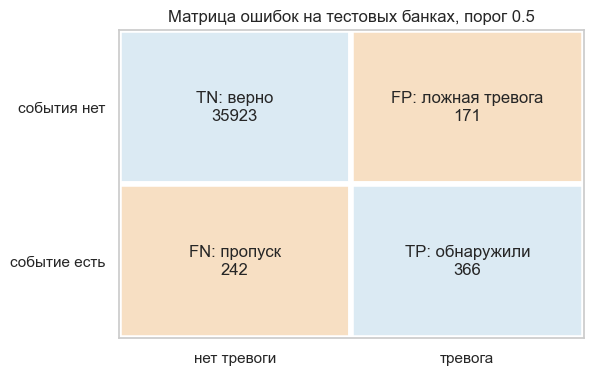

In [25]:
# @title Матрица ошибок: расчёт уже сделан, здесь только рисунок
def plot_confusion(ax, cm, title):
    names = [["TN: верно", "FP: ложная тревога"],
             ["FN: пропуск", "TP: обнаружили"]]
    colors = [["#dbeaf3", "#f7dfc3"],
              ["#f7dfc3", "#dbeaf3"]]
    for i in range(2):              # i — строка: что было на самом деле
        for j in range(2):          # j — столбец: что сказала модель
            ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1, facecolor=colors[i][j], edgecolor="white", lw=4))
            ax.text(j + 0.5, 1.5 - i, f"{names[i][j]}\n{cm[i, j]}", ha="center", va="center", fontsize=12)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5], ["нет тревоги", "тревога"])
    ax.set_yticks([1.5, 0.5], ["события нет", "событие есть"])
    ax.grid(False)
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(6, 4))
plot_confusion(ax, cm, "Матрица ошибок на тестовых банках, порог 0.5")
plt.show()

В левой верхней клетке почти все отчёты. Из-за этого доля верных ответов (**accuracy**) может выглядеть высокой даже у модели, которая никогда не поднимает тревогу.

In [26]:
accuracy = (tn + tp) / cm.sum()              # Все верные ответы / все отчёты.
accuracy_zero = (tn + fp) / cm.sum()         # "никто не лопнет" верно отвечает про всех выживших

print(f"доля верных ответов у модели:            {accuracy:.1%}")
print(f"доля верных ответов у «никто не лопнет»: {accuracy_zero:.1%}")

доля верных ответов у модели:            98.9%
доля верных ответов у «никто не лопнет»: 98.3%


98.9 % против 98.3 %: одного accuracy недостаточно, чтобы понять пользу модели.

Посмотрим на две другие доли. **Полнота (recall)** спрашивает: какую часть отчётов с последующим банкротством мы обнаружили? Это нижняя строка матрицы. **Точность (precision)** спрашивает: какая часть тревог подтвердилась? Это правый столбец.

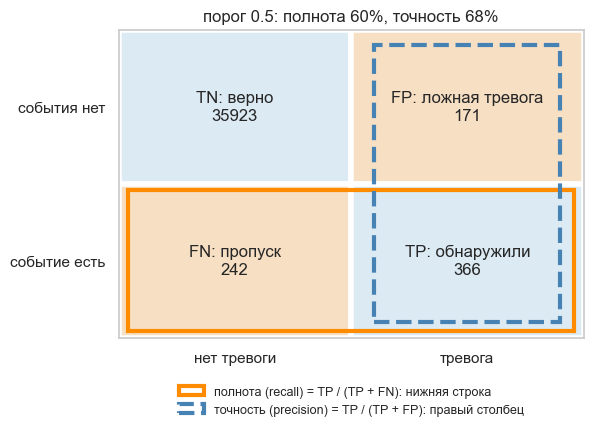

In [27]:
recall = tp / (tp + fn)                      # полнота
precision = tp / (tp + fp)                   # точность

fig, ax = plt.subplots(figsize=(6, 4))
plot_confusion(ax, cm, f"порог 0.5: полнота {recall:.0%}, точность {precision:.0%}")

# Рамки отмечают знаменатель каждой доли.
ax.add_patch(plt.Rectangle((0.04, 0.04), 1.92, 0.92, fill=False, edgecolor="darkorange", lw=3,
                           label="полнота (recall) = TP / (TP + FN): нижняя строка"))
ax.add_patch(plt.Rectangle((1.1, 0.1), 0.8, 1.8, fill=False, edgecolor="steelblue", lw=3, ls="--",
                           label="точность (precision) = TP / (TP + FP): правый столбец"))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=9, frameon=False)
plt.show()

Обнаружены 60 % отчётов с событием; подтвердились 68 % тревог. Это два разных вопроса с разными знаменателями.

Precision зависит и от редкости события: когда банкротств меньше, среди тревог может оказаться больше ложных даже при той же способности различать классы.

В `sklearn` эти числа и несколько соседних собраны в сводку `classification_report`.

In [28]:
from sklearn.metrics import classification_report

# Сводка по обоим классам; digits=3 — три знака после запятой
print(classification_report(test["y"], test["flag"],
                            target_names=["события нет", "событие есть"], digits=3))

              precision    recall  f1-score   support

 события нет      0.993     0.995     0.994     36094
событие есть      0.682     0.602     0.639       608

    accuracy                          0.989     36702
   macro avg      0.837     0.799     0.817     36702
weighted avg      0.988     0.989     0.988     36702



Строка «событие есть» повторяет наши precision и recall. Строка «события нет» — те же метрики, если событием считать выживание; при редком банкротстве они близки к единице и почти ничего не говорят. **f1-score** — среднее гармоническое precision и recall: оно низкое, если низка хотя бы одна из двух. `support` — число отчётов в классе. Строка `accuracy` — те же 98.9 %. Строки `macro avg` и `weighted avg` усредняют два класса; `weighted avg` взвешен числом строк и при редком событии почти целиком описывает отчёты без события.

### 3.3 Понизим порог

При калиброванных вероятностях порог 0.5 соответствует одинаковым ценам двух ошибок. Для казначейства пропуск банкротства может стоить намного дороже. Посмотрим, что изменится при более низком пороге.

In [29]:
rows = []
for t in [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]:
    flag = test["p"] >= t
    tp = (flag & (test["y"] == 1)).sum()
    fn = (~flag & (test["y"] == 1)).sum()
    fp = (flag & (test["y"] == 0)).sum()
    rows.append({"порог": t, "тревог": flag.sum(), "поймали": tp, "пропустили": fn,
                 "ложных тревог": fp, "полнота": tp / (tp + fn), "точность": tp / (tp + fp)})

thresholds_table = pd.DataFrame(rows).set_index("порог")
thresholds_table.round(2)

,тревог,поймали,пропустили,ложных тревог,полнота,точность
порог,,,,,,
0.50,537,366,242,171,0.60,0.68
0.20,869,478,130,391,0.79,0.55
0.10,1105,513,95,592,0.84,0.46
0.05,1398,536,72,862,0.88,0.38
0.02,2004,560,48,1444,0.92,0.28
0.01,3223,579,29,2644,0.95,0.18


Сравним две строки таблицы картинкой. Модель и её вероятности остаются прежними, меняется только граница для тревоги.

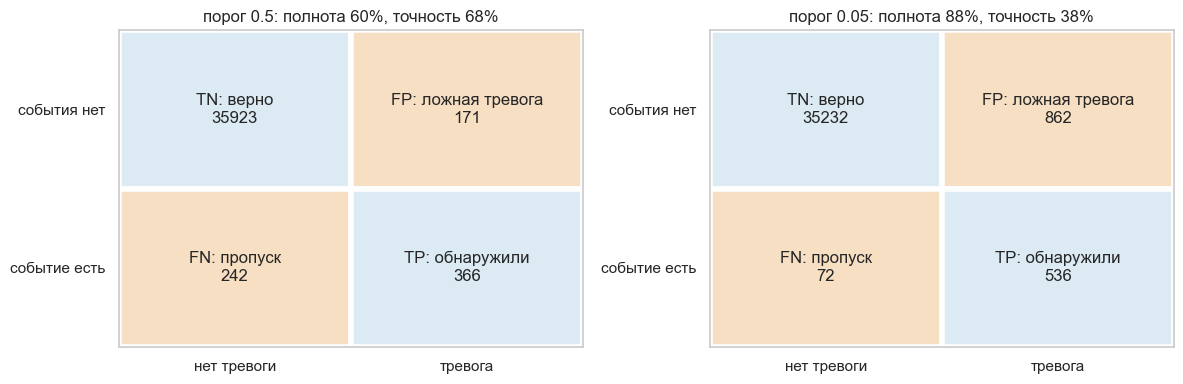

In [30]:
# @title Одни прогнозы, два порога
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, t in zip(axes, [0.5, 0.05]):
    cm_t = confusion_matrix(test["y"], (test["p"] >= t).astype(int))
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    plot_confusion(ax, cm_t, f"порог {t}: полнота {tp_t / (tp_t + fn_t):.0%}, точность {tp_t / (tp_t + fp_t):.0%}")
plt.tight_layout()
plt.show()

При пороге 0.05 обнаружены ещё 170 отчётов с событием, но добавилась 691 ложная тревога. В этом примере recall вырос с 60 % до 88 %, precision снизился с 68 % до 38 %.

Какой обмен выгоден, зависит от последствий ошибок. До §6 оставим вопрос о лучшем пороге открытым.

### 3.4 Как рано модель видит банкротство

Главный вопрос курса — можно ли предсказать банкротство заранее. Разложим тестовые отчёты с меткой 1 по тому, за сколько кварталов до банкротства они датированы, и посчитаем, какую долю из них модель помечает при двух порогах.

In [31]:
failed_rows = test[test["y"] == 1].copy()          # только отчёты перед банкротством

# Кварталов от отчёта до банкротства: дни / 91.3 с округлением вверх
days_left = (failed_rows["fail_date"] - failed_rows["repdte"]).dt.days
failed_rows["кварталов до банкротства"] = np.ceil(days_left / 91.3).astype(int)

# Среднее от True/False — доля отчётов с тревогой в каждой группе
by_quarter = failed_rows.groupby("кварталов до банкротства")
caught = pd.DataFrame({
    "порог 0.5": by_quarter["p"].apply(lambda s: (s >= 0.5).mean()),
    "порог 0.05": by_quarter["p"].apply(lambda s: (s >= 0.05).mean()),
    "отчётов": by_quarter.size()})
caught.round(2)

,порог 0.5,порог 0.05,отчётов
кварталов до банкротства,,,
1,0.78,0.96,149
2,0.72,0.93,151
3,0.55,0.90,153
4,0.37,0.74,155


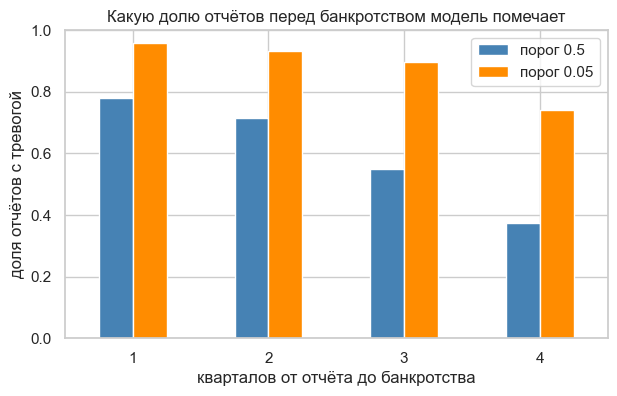

In [32]:
# @title Доля помеченных отчётов в зависимости от срока до банкротства
caught[["порог 0.5", "порог 0.05"]].plot(kind="bar", rot=0, color=["steelblue", "darkorange"])
plt.title("Какую долю отчётов перед банкротством модель помечает")
plt.xlabel("кварталов от отчёта до банкротства")
plt.ylabel("доля отчётов с тревогой")
plt.ylim(0, 1)
plt.show()

За квартал до банкротства при пороге 0.05 модель помечает почти все такие отчёты, за четыре квартала — около трёх четвертей. При пороге 0.5 доли ниже на всех сроках, а за год до краха помечена лишь треть отчётов. Признаки банкротства видны заранее, но чем раньше, тем слабее.

Вспомните задержку публикации из §1.1: отчёт за квартал до краха часто ещё не опубликован к моменту закрытия банка. Реалистичный ответ на вопрос «видно ли заранее» дают правые столбики.

## 4. Сравниваем все пороги: ROC и PR

Каждая строка таблицы порогов может стать точкой на графике. На обоих рисунках по одной из осей будет recall. Вторая ось отвечает на разные вопросы:

- **ROC:** какую долю отчётов без события мы ошибочно пометили? Это FPR = FP / (FP + TN).
- **PR (precision–recall):** какая доля поднятых тревог подтвердилась? Это precision.

Красные точки ниже соответствуют одним и тем же порогам. Сначала найдите порог 0.1 на обоих рисунках.

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

# Функции сами перебирают все пороги и возвращают по точке на каждый
fpr, tpr, _ = roc_curve(test["y"], test["p"])                          # для ROC: доли ложных тревог и пойманных
precision, recall, _ = precision_recall_curve(test["y"], test["p"])    # для PR: точность и полнота
auc = roc_auc_score(test["y"], test["p"])                              # площадь под ROC
ap = average_precision_score(test["y"], test["p"])                     # average precision
n_alive = (test["y"] == 0).sum()                                       # отчётов без события в тесте
base_rate = test["y"].mean()                                           # доля отчётов с событием

У ROC хорошая модель ближе к левому верхнему углу. У PR высокий график означает, что среди тревог много настоящих при соответствующей полноте. Серый пунктир на PR показывает базовую долю события.

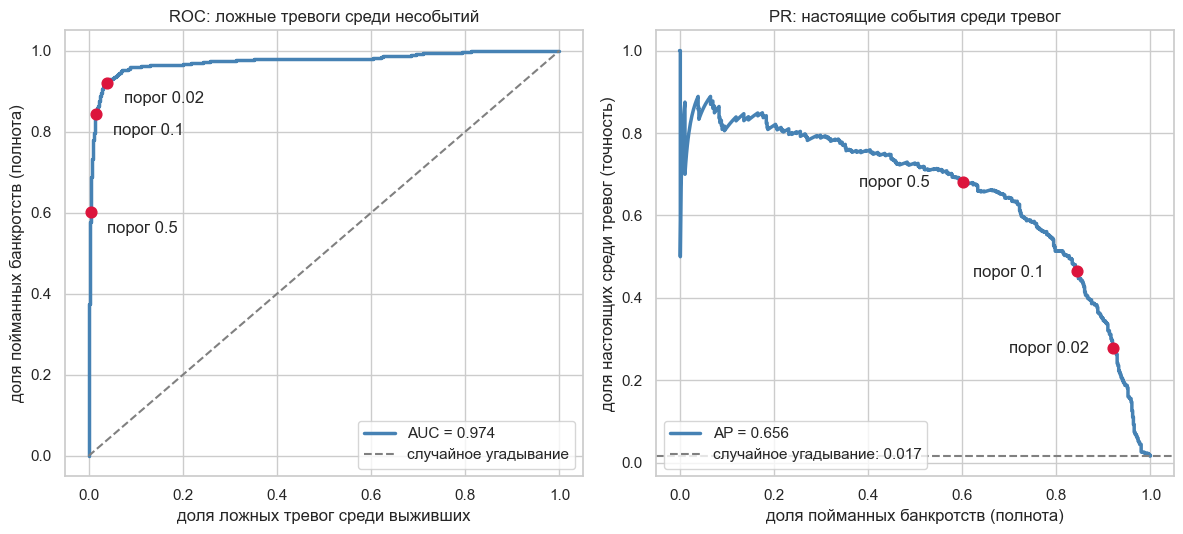

In [34]:
# @title Одни пороги на ROC- и PR-кривых
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].plot(fpr, tpr, color="steelblue", lw=2.5, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], color="grey", ls="--", label="случайное угадывание")
axes[0].set_title("ROC: ложные тревоги среди несобытий")
axes[0].set_xlabel("доля ложных тревог среди выживших")
axes[0].set_ylabel("доля пойманных банкротств (полнота)")
axes[0].legend(loc="lower right")

axes[1].plot(recall, precision, color="steelblue", lw=2.5, label=f"AP = {ap:.3f}")
axes[1].axhline(base_rate, color="grey", ls="--", label=f"случайное угадывание: {base_rate:.3f}")
axes[1].set_title("PR: настоящие события среди тревог")
axes[1].set_xlabel("доля пойманных банкротств (полнота)")
axes[1].set_ylabel("доля настоящих среди тревог (точность)")
axes[1].legend(loc="lower left")

# Одни и те же три порога на обеих картинках
for t in [0.5, 0.1, 0.02]:
    row = thresholds_table.loc[t]
    axes[0].scatter([row["ложных тревог"] / n_alive], [row["полнота"]], s=60, color="crimson", zorder=5)
    axes[0].annotate(f"порог {t}", (row["ложных тревог"] / n_alive, row["полнота"]),
                     textcoords="offset points", xytext=(12, -15))
    axes[1].scatter([row["полнота"]], [row["точность"]], s=60, color="crimson", zorder=5)
    axes[1].annotate(f"порог {t}", (row["полнота"], row["точность"]), textcoords="offset points", xytext=(-75, -4))

plt.tight_layout()
plt.show()

На ROC даже сотни ложных тревог дают небольшую долю: в знаменателе больше 36 тысяч отчётов без события. На PR видно нагрузку на того, кто разбирает тревоги: при полноте около 90 % подтверждается примерно треть сигналов.

**AUC** — площадь под ROC. Здесь она около 0.974. Её можно прочитать так: случайная пара «отчёт с событием — отчёт без события» будет правильно упорядочена по риску примерно в 97 % случаев. При равных прогнозах засчитывается половина успеха. AUC проверяет порядок, а не точность самих вероятностей.

**AP (average precision)** сводит PR-кривую к одному числу: усредняет precision с весами по приростам recall. Здесь AP около 0.66. Её читают рядом с базовой долей события, около 0.017; изменение этой доли влияет на AP.

Для фиксированной модели бутстрап по тестовым банкам даёт 95%-интервалы примерно 0.956–0.986 для AUC и 0.591–0.723 для AP. Расчёт вынесен в приложение B. Одна высокая точечная оценка ещё не говорит, что модель устойчиво работает в других условиях.

## 5. Можно ли верить числу 10 %

### 5.1 Калибровка на тестовых банках

Представьте сто отчётов, каждому из которых модель дала вероятность около 10 %. Если примерно десять таких отчётов получили метку 1, прогноз согласуется с частотой события в этой группе. Такое соответствие называется **калибровкой**.

AUC этого не проверяет: можно увеличить все прогнозы, сохранив их порядок. Поэтому сгруппируем тестовые отчёты по вероятности и в каждой группе сравним две пары чисел. Средний прогноз — с фактической долей событий. И сумму прогнозов, то есть сколько банкротств модель ожидает в группе, — с числом случившихся. Число отчётов `n` тоже нужно: частота в маленькой группе менее устойчива.

In [35]:
from statsmodels.stats.proportion import proportion_confint

# Корзины вероятности: узкие у нуля, где отчётов много, и широкие у единицы
PROB_EDGES = [0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1]

def calibration_table(y, p):
    bins = pd.cut(p, PROB_EDGES, include_lowest=True)
    table = pd.DataFrame({"y": y, "p": p, "bin": bins}).groupby("bin", observed=True).agg(
        predicted=("p", "mean"),           # средняя вероятность по модели
        actual=("y", "mean"),              # доля событий на самом деле
        n=("y", "size"),                   # отчётов в корзине
        expected_events=("p", "sum"),      # сколько событий модель ожидает: сумма вероятностей
        events=("y", "sum"))               # сколько случилось
    # 95%-интервал для доли событий (формула Уилсона)
    table["ci_low"], table["ci_high"] = proportion_confint(table["events"], table["n"], method="wilson")
    return table

calib = calibration_table(test["y"].to_numpy(), test["p"].to_numpy())
calib.round(4)

,predicted,actual,n,expected_events,events,ci_low,ci_high
bin,,,,,,,
"(-0.001, 0.001]",0.0004,0.0008,15638,5.9301,12,0.0004,0.0013
"(0.001, 0.003]",0.0018,0.0004,10657,19.4624,4,0.0001,0.0010
"(0.003, 0.01]",0.0052,0.0018,7184,36.9997,13,0.0011,0.0031
"(0.01, 0.03]",0.0159,0.0168,1552,24.6502,26,0.0115,0.0244
"(0.03, 0.1]",0.0549,0.0707,566,31.0921,40,0.0523,0.0948
"(0.1, 0.3]",0.1840,0.1916,381,70.0955,73,0.1552,0.2341
"(0.3, 1.0]",0.6721,0.6077,724,486.6044,440,0.5717,0.6426


Чтобы было видно, как выглядит плохая калибровка, возьмём те же прогнозы и умножим шансы каждого на 4. Порядок отчётов не изменится, поэтому AUC останется тем же до последнего знака, а вероятности станут завышенными. Примерно так действуют балансировка классов (приложение C) и перенос модели на рынок с другой долей банкротств.

In [36]:
odds_inflated = test["p"] / (1 - test["p"]) * 4            # шансы каждого прогноза × 4
p_inflated = (odds_inflated / (1 + odds_inflated)).to_numpy()   # обратно в вероятность

print(f"AUC нашей модели:          {roc_auc_score(test['y'], test['p']):.5f}")
print(f"AUC прогнозов с шансами × 4: {roc_auc_score(test['y'], p_inflated):.5f}")
calib_inflated = calibration_table(test["y"].to_numpy(), p_inflated)

AUC нашей модели:          0.97376
AUC прогнозов с шансами × 4: 0.97376


Рисуем обе версии. Оси в логит-шкале: она растягивает участки около 0 и около 1, поэтому 0.1 % и 60 % видны одинаково хорошо. Размер точки — число отчётов в корзине, вертикальные черты — 95%-интервал для доли событий. Формула Уилсона считает отчёты независимыми, поэтому интервалы немного узковаты: отчёты одного банка похожи. Справа — ожидаемое и фактическое число событий нашей модели в тех же корзинах.

In [37]:
# @title Функции для рисунка калибровки: пригодятся в домашнем задании и в приложении C
TICKS = [0.001, 0.01, 0.03, 0.1, 0.3, 0.8]
TICK_LABELS = ["0.1 %", "1 %", "3 %", "10 %", "30 %", "80 %"]

def plot_calibration(ax, table, label, color):
    # корзины без событий на логит-шкале не показать: оставляем их пустыми
    actual = table["actual"].where(table["actual"] > 0)
    err = [(actual - table["ci_low"].clip(lower=1e-5)).clip(lower=0),
           (table["ci_high"] - actual).clip(lower=0)]
    ax.errorbar(table["predicted"], actual, yerr=err, fmt="none", ecolor=color, alpha=0.7, capsize=3)
    ax.scatter(table["predicted"], actual, s=20 + 400 * np.sqrt(table["n"] / table["n"].max()),
               color=color, alpha=0.8, label=label, zorder=5)
    ax.plot(table["predicted"], actual, color=color, lw=1, alpha=0.6)

def finish_calibration_plot(ax, title):
    ax.plot([3e-4, 0.95], [3e-4, 0.95], "--", color="grey", label="прогноз = частота")
    ax.set_xscale("logit")
    ax.set_yscale("logit")
    ax.minorticks_off()
    ax.set_xticks(TICKS, TICK_LABELS)
    ax.set_yticks(TICKS, TICK_LABELS)
    ax.set_xlim(2e-4, 0.97)
    ax.set_ylim(1.5e-4, 0.97)
    ax.set_xlabel("средний прогноз в корзине")
    ax.set_ylabel("доля отчётов с событием")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)

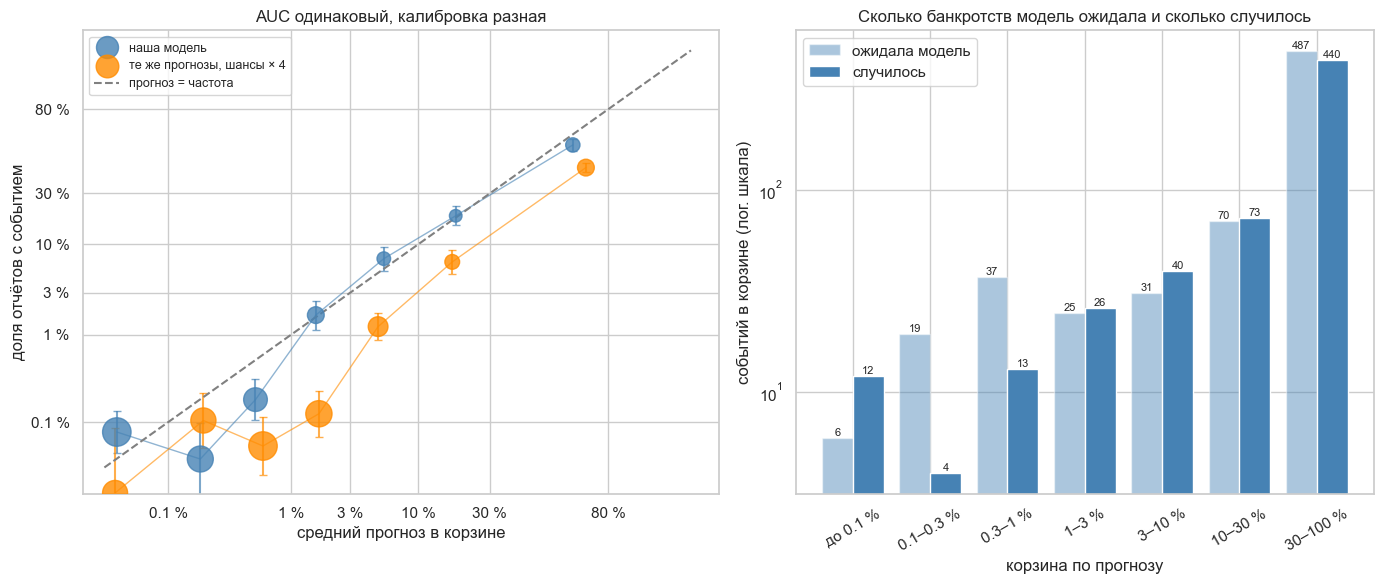

In [38]:
# @title Калибровка: наша модель и те же прогнозы с шансами × 4
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.1, 1]})

plot_calibration(axes[0], calib, "наша модель", "steelblue")
plot_calibration(axes[0], calib_inflated, "те же прогнозы, шансы × 4", "darkorange")
finish_calibration_plot(axes[0], "AUC одинаковый, калибровка разная")

# Справа: сколько событий модель ожидала и сколько случилось в каждой корзине
bin_names = ["до 0.1 %", "0.1–0.3 %", "0.3–1 %", "1–3 %", "3–10 %", "10–30 %", "30–100 %"]
x = np.arange(len(calib))
w = 0.4
axes[1].bar(x - w / 2, calib["expected_events"], w, color="steelblue", alpha=0.45, label="ожидала модель")
axes[1].bar(x + w / 2, calib["events"], w, color="steelblue", label="случилось")
for k in range(len(calib)):
    axes[1].text(x[k] - w / 2, calib["expected_events"].iloc[k], f"{calib['expected_events'].iloc[k]:.0f}",
                 ha="center", va="bottom", fontsize=8)
    axes[1].text(x[k] + w / 2, calib["events"].iloc[k], f"{calib['events'].iloc[k]:.0f}",
                 ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x, bin_names, rotation=30)
axes[1].set_yscale("log")
axes[1].set_xlabel("корзина по прогнозу")
axes[1].set_ylabel("событий в корзине (лог. шкала)")
axes[1].set_title("Сколько банкротств модель ожидала и сколько случилось")
axes[1].legend()

plt.tight_layout()
plt.show()

Оранжевые точки при том же AUC уходят под диагональ: где прогноз 72 %, событие случается у 46 % отчётов, где 17 % — у 7 %. Так выглядит плохая калибровка, и AUC её не замечает.

Синие точки нашей модели идут вдоль диагонали. В корзинах от 1 до 30 % интервалы задевают диагональ, и в штуках ожидание близко к факту: модель ждала 25, 31 и 70 банкротств, случилось 26, 40 и 73. В верхней корзине модель немного завышает риск: ждала 487, случилось 440 (обещает 67 %, получаем 61 %). В двух нижних корзинах она тоже завышает: ждала 19 и 37, случилось 4 и 13. Но это единицы событий на десятки тысяч отчётов. Совпадение хорошее, но приблизительное; называть вероятности точными нельзя.

Логистическая регрессия со свободным членом, без штрафа и весов, при конечной сошедшейся оценке уравнивает средний прогноз и долю события на обучении. Это не гарантирует совпадения по группам или на тесте. Расхождения могут возникнуть и из-за формы модели, и из-за выборочного шума.

### 5.2 Что будет в другом периоде

До сих пор обучение и тест охватывали одни и те же годы. Теперь сменим вопрос: насколько хорошо модель, обученная на прошлом, оценивала банки в 2022 году?

Обучим её на отчётах до конца 2020-го, оставим 2021 год для завершения годовых окон и применим к отчётам 2022-го. Границы обрезки тоже пересчитаем только по прошлому. По-прежнему используем даты отчётов; задержку публикации эта схема не устраняет.

In [39]:
past = df[df["repdte"] < "2021-01-01"].copy()                 # всё, что было известно до 2021 года
sample_2022 = df[df["repdte"].dt.year == 2022].copy()         # отчёты 2022 года; 2021 — зазор

# Границы обрезки — только по прошлому
lo = past[FEATURES].quantile(0.01)
hi = past[FEATURES].quantile(0.99)
past[FEATURES] = past[FEATURES].clip(lo, hi, axis=1)
sample_2022[FEATURES] = sample_2022[FEATURES].clip(lo, hi, axis=1)

model_2022 = smf.logit(formula, data=past).fit(disp=0)        # та же формула, обучение на прошлом
sample_2022["p"] = model_2022.predict(sample_2022)            # прогнозы для отчётов 2022 года

Посмотрим на Silicon Valley Bank (SVB), обанкротившийся в 2023 году. В учебных данных у него мало просроченных кредитов и большая доля ценных бумаг. Какой прогноз даёт ему модель из прошлого?

In [40]:
svb = sample_2022[sample_2022["cert"] == 24735].sort_values("repdte")   # Silicon Valley Bank
svb_last = svb.iloc[-1]                                                  # последний отчёт 2022 года
share_riskier = (sample_2022["p"] > svb_last["p"]).mean()                # доля отчётов с прогнозом выше

print(f"прогноз по последнему отчёту SVB за 2022 год: {svb_last['p']:.2%}")
print(f"у {share_riskier:.0%} отчётов 2022 года прогноз выше")
svb.set_index("repdte")[["c_equity_assets", "a_npl_gross_loans", "s_securities_assets", "p"]].round(4)

прогноз по последнему отчёту SVB за 2022 год: 0.07%
у 72% отчётов 2022 года прогноз выше


,c_equity_assets,a_npl_gross_loans,s_securities_assets,p
repdte,,,,
2022-03-31,0.0669,0.0011,0.5721,0.0009
2022-06-30,0.0726,0.0013,0.5757,0.0007
2022-09-30,0.0720,0.0011,0.5703,0.0007
2022-12-31,0.0739,0.0019,0.5612,0.0007


По последнему отчёту SVB модель даёт около 0.07 % и ставит примерно 72 % отчётов 2022 года выше него по риску. Банкротство этого банка она практически не распознала. Хорошая общая AUC не обещает, что каждый отдельный случай будет найден.

В этих шести признаках нет структуры сроков облигаций и доли незастрахованных депозитов. Объяснить весь риск банка только просрочкой, капиталом и остальными выбранными отношениями не получается. Проверка по всем годам приведена в приложении D.

Для применения ко всему рынку понадобится ещё и репрезентативная проверочная выборка: здесь обанкротившиеся банки были специально включены в панель. Поправку к вероятностям нельзя получить из одной доли события нашей панели. Эксперимент с изменением весов классов и калибровки есть в приложении C.

## 6. Как выбрать порог

### 6.1 Два решения и две цены

Вернёмся к казначейству. Пусть пропустить опасный отчёт стоит 60 условных единиц, а поднять ложную тревогу — 3. Верным решениям назначим нулевую потерю. Это учебная таблица цен; в реальной задаче её надо согласовать с тем, кто принимает решение.

Для отчёта с вероятностью $p$:

| Решение | Когда ошиблись | Ожидаемая потеря |
|---|---|---|
| Оставить лимит | банк обанкротился | $60p$ |
| Закрыть лимит | банк не обанкротился | $3(1-p)$ |

На картинке найдём вероятность, при которой эти две потери равны.

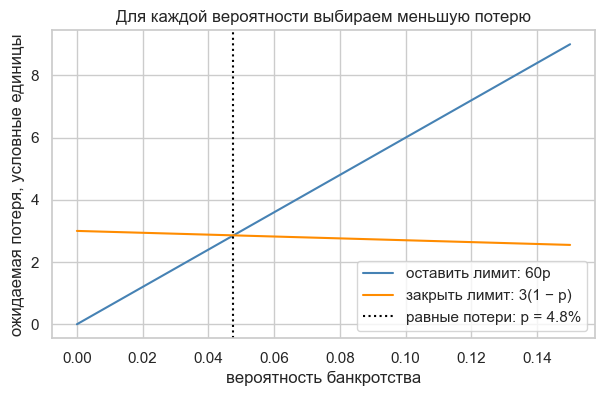

In [41]:
COST_FN = 60                                     # цена пропущенного банкротства
COST_FP = 3                                      # цена ложной тревоги
t_theory = COST_FP / (COST_FP + COST_FN)         # вероятность, при которой потери равны

# Ожидаемая потеря двух решений для каждой вероятности от 0 до 15 %
risk_grid = np.linspace(0, 0.15, 100)
plt.plot(risk_grid, COST_FN * risk_grid, label="оставить лимит: 60p", color="steelblue")
plt.plot(risk_grid, COST_FP * (1 - risk_grid), label="закрыть лимит: 3(1 − p)", color="darkorange")
plt.axvline(t_theory, color="black", ls=":", label=f"равные потери: p = {t_theory:.1%}")
plt.xlabel("вероятность банкротства")
plt.ylabel("ожидаемая потеря, условные единицы")
plt.title("Для каждой вероятности выбираем меньшую потерю")
plt.legend()
plt.show()

Слева от пересечения дешевле оставить лимит, справа — закрыть. Поэтому порог равен

$$t = \frac{C_{FP}}{C_{FP}+C_{FN}} = \frac{3}{63} \approx 0.048.$$

Пропуск в 20 раз дороже ложной тревоги, поэтому тревога оправдана уже при вероятности около 4.8 %. При равных ценах формула дала бы 0.5.

Этот расчёт предполагает, что вероятности откалиброваны для той выборки, где принимаются решения, а затраты заданы такой таблицей. В нашем примере калибровка приблизительная, поэтому и порог используем как обоснованный ориентир.

### 6.2 Что получилось на тесте

Сравним два заранее заданных порога. Цены назначили до сравнения, минимум по тесту не ищем. Потери считаем на отчёт: это условная сумма ошибок, которая может несколько раз учесть один банк. Она не равна денежным потерям портфеля.

In [42]:
rows = []
for t in [0.5, t_theory]:                               # два заранее заданных порога
    flag = test["p"] >= t                               # True — тревога
    missed = (~flag & (test["y"] == 1)).sum()           # событие было, тревоги нет
    false_alarms = (flag & (test["y"] == 0)).sum()      # тревога есть, события нет
    rows.append({"порог": t, "тревог": flag.sum(),
                 "пропущено отчётов с событием": missed,
                 "ложных тревог": false_alarms,
                 "условные потери": COST_FN * missed + COST_FP * false_alarms})
pd.DataFrame(rows).set_index("порог").round(3)

,тревог,пропущено отчётов с событием,ложных тревог,условные потери
порог,,,,
0.500000,537,242,171,15033
0.047619,1416,69,877,6771


При выбранных ценах потери снизились с 15 033 до 6 771 условной единицы. Пропусков стало меньше: 69 вместо 242. Цена этого решения — 877 ложных тревог вместо 171. Для другого соотношения цен предпочтительный порог будет другим.

На паре мы построили одну модель и задали ей три разных вопроса:

- Расставляет ли она отчёты по риску? Это видно по ROC/AUC и PR/AP.
- Соответствуют ли вероятности наблюдаемым частотам? Для этого нужна калибровка.
- При какой вероятности следует действовать? Здесь нужны цены ошибок.

Прежде чем переносить результат на будущие годы или весь рынок, придётся проверить его в этих условиях и учесть доступность отчётности. Пример SVB показывает, почему это часть самой задачи.

## Итого

1. Метка — событие в заданном горизонте: банкротство в течение 365 дней после даты отчёта. Строки, у которых горизонт ещё не закончился, выбрасываем. Фильтр «обычных банков» выбросил бы сам сигнал.
2. Логистическая регрессия переводит линейную комбинацию признаков в вероятность. Коэффициенты в `summary()` — изменения лог-шансов; через $e^{\beta}$ они читаются как множители шансов. Стандартные ошибки для панели — кластерные по банкам.
3. Изменение вероятности зависит от точки на кривой. Предельный эффект — наклон кривой; средний эффект и эффект у «среднего банка» при редком событии различаются в разы, а для шага в 1 п.п. точнее посчитать разницу двух прогнозов.
4. При редком событии доля верных ответов почти ничего не говорит. Полнота и точность отвечают на разные вопросы, и порог двигает их в разные стороны.
5. Признаки банкротства видны заранее, но слабеют с удалением от даты краха; с учётом задержки публикации реалистичен горизонт в несколько кварталов.
6. ROC и AUC проверяют порядок прогнозов, PR и AP показывают нагрузку ложных тревог. У обеих метрик есть неопределённость.
7. Калибровка проверяет сами числа. Она держится на данных, похожих на обучение, и не переносится автоматически в другой период или на весь рынок.
8. Порог выбирают по ценам ошибок: $C_{FP}/(C_{FP}+C_{FN})$ для откалиброванных вероятностей.

### Протокол для классификатора

К протоколу валидации из L03 в итоговой работе добавьте:

1. **Событие и горизонт.** Что считается событием, за какой срок, что сделано со строками без известного исхода и с задержкой публикации.
2. **Доля события** в ваших данных и в совокупности, к которой будут применять модель.
3. **Деление.** Для прогноза основная проверка — по времени, с зазором в горизонт прогноза; проверка на новых банках — дополнительная.
4. **Метрики.** AUC и AP рядом, с интервалами бутстрапа по банкам; таблица и рисунок калибровки.
5. **Порог.** Кто принимает решение, чьи цены ошибок и в чём считаются потери: в отчётах или в банках.
6. **Ограничения.** Какие виды риска выбранные признаки не видят (пример SVB).

---

# Домашнее задание

Повторите основной путь для банкротства в течение двух лет: `failed_next_8q`. Обязательная часть — задания 1–5, задание 6 дополнительное. Код из лекции можно копировать и менять.

Начните с тех же шести признаков. Главное — понимать, к каким строкам относятся вероятности и что изменилось при переходе к другому горизонту. Заранее предполагать улучшение или ухудшение метрик не нужно.

### 1. Общая таблица для двух горизонтов

`TODO(hw4-a)`. Определите последнюю дату отчёта, для которой известен исход за полные два года. Оставьте эти строки, примените отбор из §1.3 и один раз выделите 30 % банков в тест. По обучению найдите границы обрезки признаков и примените их к обеим частям.

Сохраните обе колонки меток: `failed_next_4q` и `failed_next_8q`. Выведите числа строк и банков, доли обоих событий в обучении и тесте. Объясните выбранную границу даты.

Во всех дальнейших сравнениях у двух моделей должны совпадать строки, признаки, тестовые банки и обработка признаков.

In [43]:
# TODO(hw4-a): общие строки с известным 8q, один split, обрезка по train, доли обоих событий.

> _Ваш ответ (2–3 предложения):_

### 2. Две логистические модели

`TODO(hw4-b)`. На одних обучающих строках оцените две модели `smf.logit`: с откликом 8q и с откликом 4q, с кластерными по банкам ошибками. Получите прогнозы на общих тестовых строках.

Для модели 8q объясните знак коэффициента при капитале и множитель шансов при +1 п.п. капитала (как в §2.2).

In [44]:
# TODO(hw4-b): две модели на общей таблице; множитель шансов при +1 п.п. капитала для 8q.

> _Ваш ответ (2–3 предложения):_

### 3. Ошибки и порядок прогнозов

`TODO(hw4-c)`. Для модели 8q покажите матрицу ошибок при пороге 0.5 и посчитайте precision и recall. Для обеих моделей составьте таблицу «горизонт / доля события / AUC / AP». Постройте PR-кривые на одном рисунке, отметьте обе базовые доли события.

Как изменились метрики? Учитывайте, что метка 8q обозначает другое событие, а AP зависит от его частоты. Большая AP сама по себе не доказывает, что модель лучше различает банки.

In [45]:
# TODO(hw4-c): матрица 8q, precision/recall; сравнение AUC, AP и долей события; две PR-кривые.

> _Ваш ответ (3–4 предложения):_

### 4. Калибровка

`TODO(hw4-d)`. Для модели 8q постройте таблицу и рисунок калибровки готовыми функциями из §5.1. Как там, создайте поле `fig, ax = plt.subplots(figsize=(7, 6))`, передайте `ax` первым аргументом в обе функции и закончите `plt.show()`.

Выберите одну группу с заметным расхождением прогноза и факта. Укажите обе величины и число отчётов. Можно ли по этой таблице считать прогнозы достаточно точными для решений?

In [46]:
# TODO(hw4-d): calibration_table, plot_calibration, finish_calibration_plot для прогноза 8q.

> _Ваш ответ (2–3 предложения):_

### 5. Решение по модели

`TODO(hw4-e)`. Используйте учебные цены из §6: пропуск стоит 60, ложная тревога — 3. Для модели 8q сравните порог из формулы с порогом 0.5: сколько тревог, пропусков, ложных тревог и условных потерь?

Объясните, чем оплачивается сокращение пропусков и как замеченные в задании 4 ошибки калибровки ограничивают применение формулы. Если хотите взять свои цены, назовите того, кто принимает решение, и обоснуйте суммы. Все потери по-прежнему считаются на отчёт.

In [47]:
# TODO(hw4-e): порог из цен ошибок; таблица последствий двух порогов для 8q.

> _Ваш ответ (3–4 предложения):_

### 6. Дополнительно: наклон и конечный шаг

`TODO(hw4-f)`. По образцу §2.4 посчитайте средний предельный эффект капитала у модели 8q и эффект у среднего набора признаков. Затем получите точное среднее изменение прогнозов при прибавке 0.01 к капиталу всех обучающих строк, сохранив остальные признаки.

Объясните, почему предельный эффект и изменение при конечном шаге могут различаться. Для сравнения среднего наклона с конечным шагом используйте одни и те же строки.

In [48]:
# TODO(hw4-f), дополнительно: средний наклон, наклон у средних признаков, конечный шаг на тех же строках.

> _Ваш ответ:_

---

# Дополнительные разборы

Эти разделы можно читать по отдельности после выполнения основной части:

- A. Как подбираются коэффициенты: log loss.
- B. Неопределённость AUC и AP: бутстрап по банкам.
- C. Что балансировка классов делает с вероятностями.
- D. Проверка на будущих годах.
- E. Скоринговая карта.

Домашние ячейки оставлены пустыми и не нужны приложениям. Для независимого чтения приложений сохраняйте переменные основной части; в домашней работе используйте свои имена таблиц и моделей.

## Приложение A. Как подбираются коэффициенты

Модель должна давать высокую вероятность тем отчётам, после которых банк обанкротился, и низкую — остальным. Каждый отчёт вносит множитель: $p_i$, если $y_i=1$, и $1-p_i$, если $y_i=0$.

При независимых наблюдениях произведение этих множителей — **правдоподобие**. В нашей панели кварталы одного банка зависимы, поэтому произведение служит составным правдоподобием: удобным критерием подбора коэффициентов, а не полной моделью совместного распределения кварталов. Зависимость внутри банка учитываем при оценке стандартных ошибок.

Минимизировать минус логарифм произведения удобнее, чем максимизировать само произведение. Получается **log loss**:

$$-\sum_i\left[y_i\ln p_i+(1-y_i)\ln(1-p_i)\right].$$

Нарисуем этот критерий для разных наклонов. Свободный член оставим таким, каким его нашла модель с одним капиталом. В коде используем равную по смыслу запись $\ln(1+e^{z_i})-y_i z_i$: `np.logaddexp` считает её устойчиво даже при больших $|z_i|$.


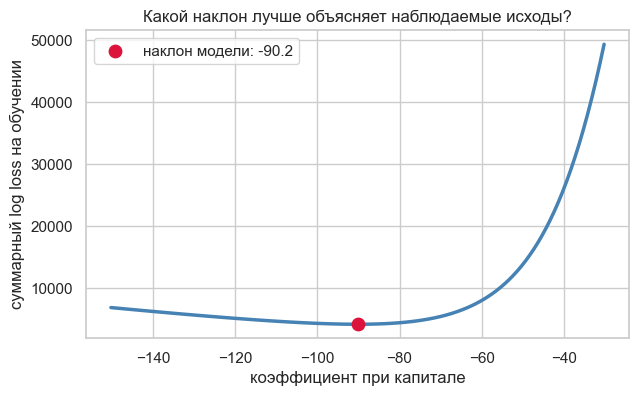

In [49]:
loss_x = train["c_equity_assets"].to_numpy()             # капитал обучающих отчётов
loss_y = train["y"].to_numpy()                           # их метки 0/1
loss_b0 = logit1.params["Intercept"]                     # оценки модели с одним капиталом
loss_b1 = logit1.params["c_equity_assets"]

# log loss при заданных коэффициентах: ln(1 + e^z) - y*z, сумма по всем отчётам
def log_loss_at(intercept, slope):
    z = intercept + slope * loss_x
    return np.sum(np.logaddexp(0, z) - loss_y * z)

# Сечение: свободный член держим на оценке, перебираем наклон
slopes = np.linspace(loss_b1 - 60, loss_b1 + 60, 120)
losses = [log_loss_at(loss_b0, slope) for slope in slopes]

plt.plot(slopes, losses, color="steelblue", lw=2.5)
plt.scatter([loss_b1], [log_loss_at(loss_b0, loss_b1)], s=80, color="crimson", zorder=5,
            label=f"наклон модели: {loss_b1:.1f}")
plt.title("Какой наклон лучше объясняет наблюдаемые исходы?")
plt.xlabel("коэффициент при капитале")
plt.ylabel("суммарный log loss на обучении")
plt.legend()
plt.show()

Красная точка лежит у дна. Но это только сечение: свободный член мы зафиксировали. При обучении программа подбирает оба коэффициента, и log loss — поверхность над плоскостью «свободный член × наклон», как чаша RSS во второй лекции. Посчитаем её на сетке 70 × 70.

In [50]:
# Сетка коэффициентов вокруг оценки модели
b0_grid = np.linspace(loss_b0 - 1.3, loss_b0 + 1.3, 70)
b1_grid = np.linspace(loss_b1 - 20, loss_b1 + 20, 70)
B0, B1 = np.meshgrid(b0_grid, b1_grid)                   # решётка всех пар (свободный член, наклон)

# Двойной цикл: log loss в каждой из 4900 точек решётки
loss_surface = np.zeros(B0.shape)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        loss_surface[i, j] = log_loss_at(B0[i, j], B1[i, j])

print("минимум на сетке:", round(loss_surface.min(), 1))
print("у оценки модели: ", round(log_loss_at(loss_b0, loss_b1), 1))

минимум на сетке: 4158.1
у оценки модели:  4158.1


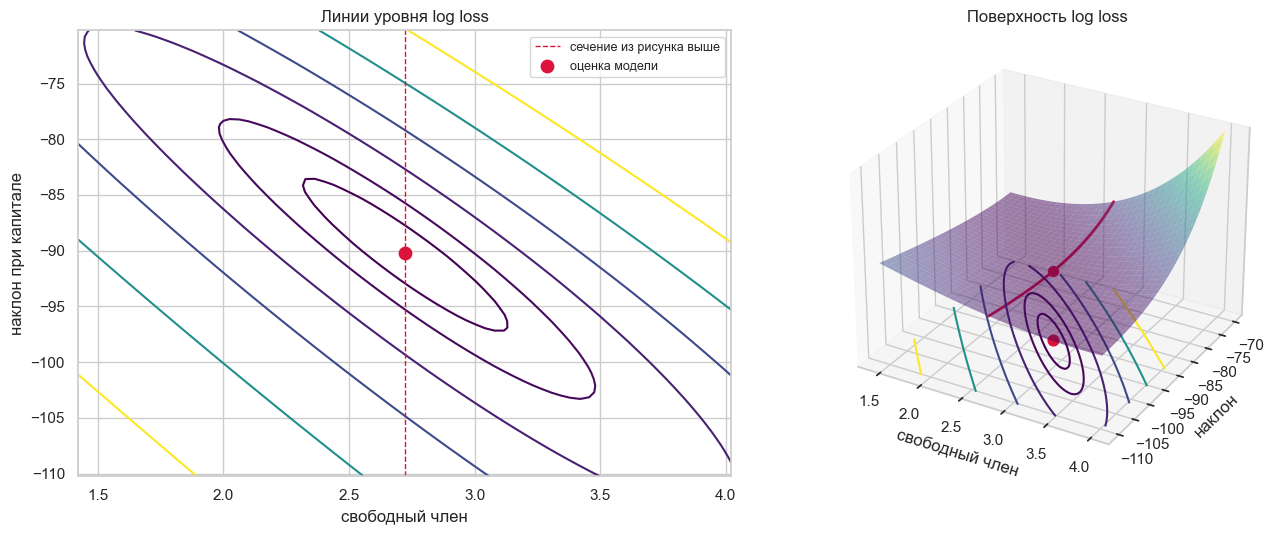

In [51]:
# @title Чаша log loss: линии уровня и поверхность
levels = loss_surface.min() * np.array([1.003, 1.01, 1.03, 1.07, 1.15, 1.3])   # линии гуще у дна
floor = loss_surface.min() - 0.6 * (loss_surface.max() - loss_surface.min())   # высота «пола» под чашей
section = [log_loss_at(loss_b0, s) for s in b1_grid]      # сечение из предыдущего рисунка

fig = plt.figure(figsize=(14, 5.5))

# Слева: линии уровня; пунктир — то самое сечение при зафиксированном свободном члене
ax1 = fig.add_subplot(1, 2, 1)
ax1.contour(B0, B1, loss_surface, levels=levels, cmap="viridis")
ax1.axvline(loss_b0, color="crimson", ls="--", lw=1, label="сечение из рисунка выше")
ax1.scatter([loss_b0], [loss_b1], color="crimson", s=80, zorder=5, label="оценка модели")
ax1.set_xlabel("свободный член")
ax1.set_ylabel("наклон при капитале")
ax1.set_title("Линии уровня log loss")
ax1.legend(loc="upper right", fontsize=9)

# Справа: поверхность, её линии уровня на «полу», дно и сечение
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(B0, B1, loss_surface, cmap="viridis", alpha=0.5, edgecolor="none")
ax2.contour(B0, B1, loss_surface, levels=levels, zdir="z", offset=floor, cmap="viridis")
ax2.plot([loss_b0] * len(b1_grid), b1_grid, section, color="crimson", lw=2)
ax2.scatter([loss_b0], [loss_b1], [loss_surface.min()], color="crimson", s=50, depthshade=False)
ax2.scatter([loss_b0], [loss_b1], [floor], color="crimson", s=60, depthshade=False)
ax2.set_zlim(floor, loss_surface.max())
ax2.set_zticks([])                                       # абсолютная высота чаши не важна
ax2.set_xlabel("свободный член")
ax2.set_ylabel("наклон")
ax2.set_title("Поверхность log loss")
ax2.view_init(elev=28, azim=-60)

plt.tight_layout()
plt.show()

Слева линии уровня, справа та же поверхность, её линии уровня спроецированы на «пол».

У чаши одно дно, и оценка модели сидит именно в нём. Это не случайность: log loss логистической регрессии — выпуклая функция коэффициентов, как RSS у МНК. Поэтому численный поиск из любой разумной стартовой точки приходит в одно и то же место.

Эллипсы вытянуты по диагонали: свободный член и наклон связаны. Капитал во всех отчётах далёк от нуля, от 2.7 до 24 %, и если немного поднять свободный член, почти то же качество даст чуть более крутой наклон. Ту же диагональ мы видели у чаши RSS во второй лекции.

Красная линия на поверхности и пунктир слева — сечение из предыдущего рисунка, разрез чаши при зафиксированном свободном члене. Его дно совпадает с дном чаши, потому что разрез проведён через оценённый свободный член.

Разница с МНК в том, как ищут дно. У RSS есть готовая формула, у log loss её нет, и программа шагает вниз по чаше, пока не упрётся в дно. Если вызвать `.fit(disp=1)`, строка `Iterations` покажет число шагов.

## Приложение B. Неопределённость AUC и AP

Метрики посчитаны на одном наборе тестовых банков. Чтобы увидеть, насколько они чувствительны к его составу, будем выбирать банки с возвращением и каждый раз пересчитывать метрики. Вместе с банком берём всю его историю: соседние кварталы нельзя считать независимыми наблюдениями.

Это **условный бутстрап для уже обученной модели**. Мы не обучаем её заново; неопределённость обучения и перенос в другой период этот интервал не учитывает. Если в повторе окажется только один класс, AUC не определён — такой повтор пропустим.


In [52]:
by_bank = test.set_index("cert")
test_banks = test["cert"].unique()
rng = np.random.default_rng(SEED)
boot_auc, boot_ap = [], []

for _ in range(500):
    chosen = rng.choice(test_banks, size=len(test_banks), replace=True)
    sample = by_bank.loc[chosen]  # выбранный дважды банк войдёт дважды
    if sample["y"].nunique() < 2:
        continue
    boot_auc.append(roc_auc_score(sample["y"], sample["p"]))
    boot_ap.append(average_precision_score(sample["y"], sample["p"]))

print(f"Повторов с двумя классами: {len(boot_auc)} из 500")
for name, estimate, values in [("AUC", auc, boot_auc), ("AP", ap, boot_ap)]:
    left, right = np.percentile(values, [2.5, 97.5])
    print(f"{name}: {estimate:.3f}; 95%-интервал [{left:.3f}, {right:.3f}]")


Повторов с двумя классами: 500 из 500
AUC: 0.974; 95%-интервал [0.956, 0.986]
AP: 0.656; 95%-интервал [0.591, 0.723]


Ширина интервала помогает понять масштаб неопределённости. Для сравнения двух моделей нужен интервал именно для разности их метрик: обе модели проверяют на одних и тех же выбранных банках. Такой пример будет в приложении E.


## Приложение C. Что меняет балансировка классов

`class_weight="balanced"` придаёт редкому классу больший вес, чтобы суммарный вес двух классов стал одинаковым. Модель решает другую задачу: сильнее штрафует ошибки на отчётах с будущим банкротством.

Сравним две логистические регрессии из `sklearn`. В обеих есть стандартный ridge-штраф, поэтому признаки сначала стандартизуем. Отличаться будет только вес классов. Числа `predict_proba` взвешенной модели нельзя автоматически считать вероятностями для исходной выборки.


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plain = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
plain.fit(train[FEATURES], train["y"])
p_plain = plain.predict_proba(test[FEATURES])[:, 1]

balanced = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
balanced.fit(train[FEATURES], train["y"])
p_balanced = balanced.predict_proba(test[FEATURES])[:, 1]

pd.DataFrame({
    "AUC": [roc_auc_score(test["y"], p_plain), roc_auc_score(test["y"], p_balanced)],
    "средняя вероятность": [p_plain.mean(), p_balanced.mean()],
    "доля событий": [test["y"].mean(), test["y"].mean()],
}, index=["обычная", "с весами классов"]).round(3)


,AUC,средняя вероятность,доля событий
обычная,0.974,0.018,0.017
с весами классов,0.975,0.134,0.017


Одного среднего мало: сравним прогноз и фактическую долю событий в корзинах вероятности тем же способом, что в §5.1.


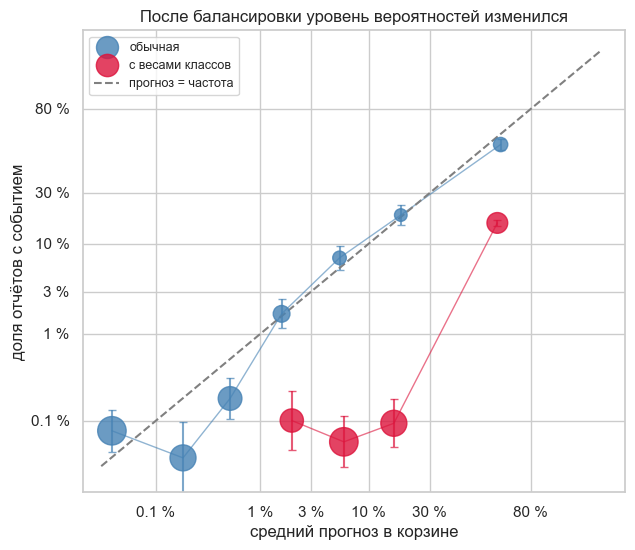

In [54]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_calibration(ax, calibration_table(test["y"].to_numpy(), p_plain), "обычная", "steelblue")
plot_calibration(ax, calibration_table(test["y"].to_numpy(), p_balanced), "с весами классов", "crimson")
finish_calibration_plot(ax, "После балансировки уровень вероятностей изменился")
plt.show()

В этом примере AUC близки, а прогнозы модели с весами заметно выше наблюдаемых частот. В трёх нижних корзинах у неё событий нет вовсе, и на логит-шкале эти точки не показать. Близкие AUC означают близкое качество ранжирования в целом; это не означает, что порядок всех банков совпал.

Весами можно менять акцент при обучении. Но в конечной выборке они могут изменить и коэффициенты, и ранжирование — балансировка не сводится гарантированно к одному сдвигу вероятностей. Если нужны сами вероятности, проверяем калибровку на данных с целевой долей события. Если нужно учесть цену ошибок, у откалиброванной модели можно выбрать порог, как в §6.


## Приложение D. Проверка по годам

В §5.2 мы разобрали один перенос во времени. Повторим его для каждого доступного года: для прогнозов по отчётам года $Y$ обучимся на отчётах до $Y-2$ включительно. Год $Y-1$ оставим как зазор, чтобы годовые исходы обучающих отчётов успели стать известными.

Берём все банки: здесь проверяется применение модели к будущим отчётам, в том числе уже знакомых банков. Границы обрезки хвостов каждый раз считаем только по прошлому. Таблица покажет ещё и число кварталов: **2025 год в этих данных неполный**, поэтому его строку нельзя считать итогом полного года.


In [55]:
wf_year = df["repdte"].dt.year
wf_rows = []
for forecast_year in range(2007, 2026):
    wf_past = df[wf_year <= forecast_year - 2].copy()
    wf_now = df[wf_year == forecast_year].copy()
    if wf_past.empty or wf_now.empty or wf_past["y"].nunique() < 2:
        continue

    wf_lower = wf_past[FEATURES].quantile(0.01)
    wf_upper = wf_past[FEATURES].quantile(0.99)
    wf_past[FEATURES] = wf_past[FEATURES].clip(wf_lower, wf_upper, axis=1)
    wf_now[FEATURES] = wf_now[FEATURES].clip(wf_lower, wf_upper, axis=1)
    wf_model = smf.logit(formula, data=wf_past).fit(disp=0)
    wf_p = wf_model.predict(wf_now)
    wf_failed = wf_now.loc[wf_now["y"] == 1, "cert"].nunique()
    wf_auc = np.nan
    if wf_failed >= 10 and wf_now["y"].nunique() == 2:
        wf_auc = roc_auc_score(wf_now["y"], wf_p)
    wf_rows.append({
        "год отчётов": forecast_year,
        "кварталов": wf_now["repdte"].dt.to_period("Q").nunique(),
        "последний отчёт": wf_now["repdte"].max().date(),
        "доля событий": wf_now["y"].mean(),
        "средняя вероятность": wf_p.mean(),
        "банков с событием": wf_failed,
        "AUC": wf_auc,
    })

wf_table = pd.DataFrame(wf_rows).set_index("год отчётов")
wf_table.round(4)


,кварталов,последний отчёт,доля событий,средняя вероятность,банков с событием,AUC
год отчётов,,,,,,
2007,4,2007-12-31,0.0071,0.0049,30,0.8885
2008,4,2008-12-31,0.0561,0.0315,167,0.8867
2009,4,2009-12-31,0.0942,0.0711,257,0.9365
2010,4,2010-12-31,0.0728,0.0803,195,0.9620
2011,4,2011-12-31,0.0471,0.0569,110,0.9843
2012,4,2012-12-31,0.0206,0.0305,48,0.9908
2013,4,2013-12-31,0.0126,0.0182,27,0.9869
2014,4,2014-12-31,0.0081,0.0099,15,0.9945
2015,4,2015-12-31,0.0030,0.0065,5,NaN


AUC выводим только для лет хотя бы с десятью банками с событием. Это наше правило показа, а не гарантия точности метрики. В остальные годы оставляем пропуск.

На графике сравним средний прогноз с наблюдаемой частотой. Для больших различий удобна логарифмическая шкала; годы с нулевой частотой на ней показать нельзя, но нули остаются в таблице.


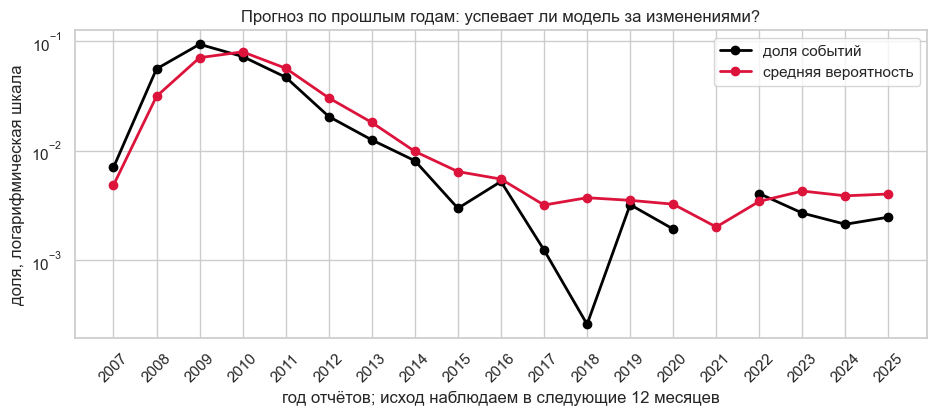

In [56]:
plt.figure(figsize=(11, 4))
plt.plot(wf_table.index, wf_table["доля событий"].replace(0, np.nan),
         "o-", color="black", lw=2, label="доля событий")
plt.plot(wf_table.index, wf_table["средняя вероятность"],
         "o-", color="crimson", lw=2, label="средняя вероятность")
plt.yscale("log")
plt.xticks(wf_table.index, rotation=45)
plt.title("Прогноз по прошлым годам: успевает ли модель за изменениями?")
plt.xlabel("год отчётов; исход наблюдаем в следующие 12 месяцев")
plt.ylabel("доля, логарифмическая шкала")
plt.legend()
plt.show()


В начале волны банкротств модель, обученная на более спокойных годах, занижает средний риск. После волны он долго остаётся завышенным. При этом ранжирование в некоторые годы может быть хорошим: порядок и уровень вероятностей — разные свойства.

Сравнение средних проверяет только общий уровень. Даже совпавшие средние не гарантируют калибровку по отдельным группам риска. Для будущего применения важны обе проверки и понимание того, какие изменения модель вообще может заметить по своим признакам.


## Приложение E. Скоринговая карта

Логистическую модель можно записать как таблицу баллов. Вместо точного значения капитала используем диапазон: например, 5–7 %. Для каждого диапазона модель оценит коэффициент, который затем переведём в баллы.

Возьмём четыре признака и договоримся: **+20 баллов соответствуют удвоению шансов банкротства**. Здесь больше баллов означает больше риска. Баллы округлим до целых, поэтому рассчитанная по ним вероятность будет приближением к исходной модели.

Сначала зададим диапазоны и посмотрим, сколько отчётов и событий в каждом диапазоне капитала.


In [57]:
def to_bins(table):
    out = pd.DataFrame(index=table.index)
    out["equity_bin"] = pd.cut(
        table["c_equity_assets"], [-np.inf, 0.05, 0.07, 0.09, 0.12, np.inf],
        right=False, labels=["<5%", "5-7%", "7-9%", "9-12%", "≥12%"])
    out["npl_bin"] = pd.cut(
        table["a_npl_gross_loans"], [-np.inf, 0.01, 0.02, 0.04, 0.08, np.inf],
        right=False, labels=["<1%", "1-2%", "2-4%", "4-8%", "≥8%"])
    out["roa_bin"] = pd.cut(
        table["e_roa"], [-np.inf, -0.01, 0, 0.005, 0.01, np.inf],
        right=False, labels=["<-1%", "-1-0%", "0-0.5%", "0.5-1%", "≥1%"])
    out["brokered_bin"] = pd.cut(
        table["l_brokered_share"], [-np.inf, 1e-9, 0.05, 0.15, np.inf],
        right=False, labels=["0", "0-5%", "5-15%", "≥15%"])
    return out

card_train = to_bins(train)
card_train["y"] = train["y"]
card_train["cert"] = train["cert"]
card_test = to_bins(test)
card_train.groupby("equity_bin", observed=True)["y"].agg(["mean", "size"]).round(4)


,mean,size
equity_bin,,
<5%,0.4388,2115
5-7%,0.0485,4862
7-9%,0.0078,23373
9-12%,0.0023,34945
≥12%,0.0013,20147


Низкий капитал связан с более частыми событиями. Остальные признаки тоже разобьём на диапазоны и включим в одну модель через `C()`, как во второй лекции.

Для каждого признака выберем базовый диапазон с нулевыми баллами. Баллы остальных диапазонов будут относительными: $\text{баллы}=\beta\cdot20/\ln2$. Например, коэффициент $\ln2$ даёт 20 баллов. Для удобства округлим до целых.


In [58]:
REFERENCE = {"equity_bin": "≥12%", "npl_bin": "<1%", "roa_bin": "≥1%", "brokered_bin": "0"}
card_formula = "y ~ " + " + ".join(
    f"C({col}, Treatment('{ref}'))" for col, ref in REFERENCE.items())
card_model = smf.logit(card_formula, data=card_train).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": card_train["cert"]})

card_rows = []
for col, ref in REFERENCE.items():
    for level in card_train[col].cat.categories:
        coefficient = f"C({col}, Treatment('{ref}'))[T.{level}]"
        beta = card_model.params.get(coefficient, 0.0)
        card_rows.append({"признак": col, "диапазон": level,
                          "баллы": int(round(beta * 20 / np.log(2)))})

card = pd.DataFrame(card_rows)
card.set_index(["признак", "диапазон"])


баллы
признак      диапазон       
equity_bin   <5%         123
             5-7%         67
             7-9%         43
             9-12%        17
             ≥12%          0
npl_bin      <1%           0
             1-2%         34
             2-4%         54
             4-8%         75
             ≥8%         101
roa_bin      <-1%         37
             -1-0%         5
             0-0.5%        0
             0.5-1%      -22
             ≥1%           0
brokered_bin 0             0
             0-5%         10
             5-15%        13
             ≥15%         30

Получилась карта: найдём диапазон каждого признака и сложим баллы. Но перед использованием посмотрим на необычный результат: диапазон ROA 0.5–1 % получил отрицательные баллы относительно базы «от 1 %». Это значит, что модель связывает его с меньшим риском при одинаковых остальных категориях.

Проверим долю событий по ROA без модели и кластерные z-статистики коэффициентов.


In [59]:
print(card_train.groupby("roa_bin", observed=True)["y"].agg(["mean", "size"]).round(4))
card_model.tvalues.filter(like="roa_bin").round(1)


           mean   size
roa_bin               
<-1%     0.2126   5283
-1-0%    0.0256   4653
0-0.5%   0.0072  12494
0.5-1%   0.0014  25196
≥1%      0.0023  37816


C(roa_bin, Treatment('≥1%'))[T.<-1%]      6.5
C(roa_bin, Treatment('≥1%'))[T.-1-0%]     0.9
C(roa_bin, Treatment('≥1%'))[T.0-0.5%]    0.0
C(roa_bin, Treatment('≥1%'))[T.0.5-1%]   -3.3
dtype: float64

Оценка для диапазона 0.5–1 % заметно отличается от нуля относительно своей стандартной ошибки. Это повод изучить связь, но не доказательство того, что высокая прибыльность повышает риск: результат зависит от данных, признаков и выбранных границ диапазонов.

Если нужен монотонный рост баллов при ухудшении признака, границы или модель придётся изменить и проверить заново. Из одной таблицы нельзя решить, какая форма вернее.

Посчитаем карту для Wakulla и Arrow Bank на 31 декабря 2009 года. К их признакам применим те же границы обрезки, что к обучению и тесту. Рядом покажем точную вероятность категориальной модели и приближение по целым баллам.


In [60]:
point_maps = {
    col: card.loc[card["признак"] == col].set_index("диапазон")["баллы"].to_dict()
    for col in REFERENCE
}
intercept = card_model.params["Intercept"]

def card_points(binned):
    return pd.DataFrame({
        col: binned[col].astype("object").map(point_maps[col]) for col in REFERENCE
    }, index=binned.index)

def probability_from_score(score):
    z = intercept + score * np.log(2) / 20
    return 1 / (1 + np.exp(-z))

two_banks = panel.loc[
    panel["cert"].isin([21777, 7074]) & (panel["repdte"] == "2009-12-31")].copy()
two_banks[FEATURES] = two_banks[FEATURES].clip(lower, upper, axis=1)
two_bins = to_bins(two_banks)
two_points = card_points(two_bins)
two_total = two_points.sum(axis=1, min_count=len(REFERENCE))
two_exact = card_model.predict(two_bins)

bank_names = {21777: "Wakulla Bank", 7074: "Arrow Bank"}
two_result = two_points.copy()
two_result.insert(0, "банк", two_banks["cert"].map(bank_names))
two_result["сумма баллов"] = two_total
two_result["вероятность по модели, %"] = 100 * two_exact
two_result["вероятность по баллам, ≈%"] = 100 * probability_from_score(two_total)
two_result.set_index("банк").round(3)


,equity_bin,npl_bin,roa_bin,brokered_bin,сумма баллов,"вероятность по модели, %","вероятность по баллам, ≈%"
банк,,,,,,,
Arrow Bank,43,0,0,0,43,0.099,0.101
Wakulla Bank,67,101,37,13,218,29.985,30.307


Округление слегка меняет вероятности. Теперь по горизонтали можно отложить сумму баллов, а по вертикали — соответствующую ей вероятность. Оценивать на тесте будем именно эту округлённую карту, которую только что показали.


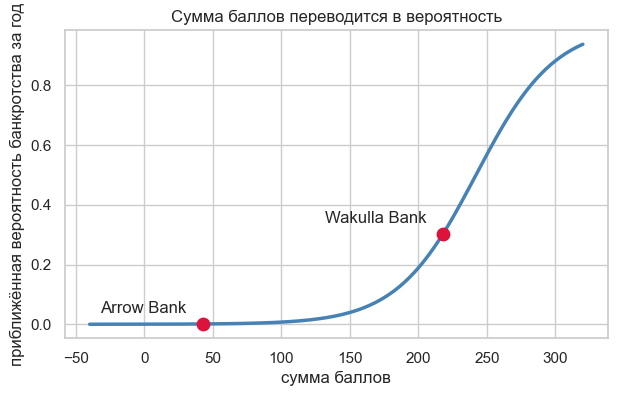

AUC: округлённая карта 0.971; модель с шестью признаками 0.974


In [61]:
score_grid = np.linspace(-40, 320, 200)
plt.plot(score_grid, probability_from_score(score_grid), color="steelblue", lw=2.5)
for _, row in two_result.iterrows():
    score = row["сумма баллов"]
    probability = row["вероятность по баллам, ≈%"] / 100
    plt.scatter([score], [probability], s=80, color="crimson", zorder=5)
    plt.annotate(row["банк"], (score, probability), textcoords="offset points",
                 xytext=(-12, 8), ha="right")
plt.title("Сумма баллов переводится в вероятность")
plt.xlabel("сумма баллов")
plt.ylabel("приближённая вероятность банкротства за год")
plt.show()

card_test_points = card_points(card_test)
card_test_total = card_test_points.sum(axis=1, min_count=len(REFERENCE))
p_card = probability_from_score(card_test_total)
auc_card = roc_auc_score(test["y"], p_card)
print(f"AUC: округлённая карта {auc_card:.3f}; модель с шестью признаками {auc:.3f}")


Насколько убедительна разница AUC? Используем бутстрап по банкам из приложения B. В каждом повторе обе уже обученные модели проверяем на одном и том же наборе банков и сохраняем разность метрик.


In [62]:
card_comparison = test.assign(p_card=p_card).set_index("cert")
card_test_banks = test["cert"].unique()
card_rng = np.random.default_rng(SEED)
auc_differences = []

for _ in range(500):
    chosen = card_rng.choice(card_test_banks, size=len(card_test_banks), replace=True)
    sample = card_comparison.loc[chosen]
    if sample["y"].nunique() < 2:
        continue
    difference = (roc_auc_score(sample["y"], sample["p"])
                  - roc_auc_score(sample["y"], sample["p_card"]))
    auc_differences.append(difference)

left, right = np.percentile(auc_differences, [2.5, 97.5])
print(f"AUC полной модели минус AUC карты: {auc - auc_card:.3f}")
print(f"95%-интервал разности: [{left:.3f}, {right:.3f}]")
print(f"Повторов с двумя классами: {len(auc_differences)} из 500")


AUC полной модели минус AUC карты: 0.003
95%-интервал разности: [-0.002, 0.009]
Повторов с двумя классами: 500 из 500


Интервал включает ноль: этот тест не даёт убедительных свидетельств разницы AUC. Это не доказывает равенство моделей. Интервал относится к двум фиксированным моделям и этому способу формирования теста; другие годы могут дать другой результат.

Карта делает расчёт прозрачным: видно, сколько баллов принёс каждый признак. За простоту приходится платить грубыми диапазонами и округлением. Перед применением ей нужны те же проверки калибровки и переноса во времени, что и исходной модели. Вероятности здесь по-прежнему относятся к нашей учебной выборке.
